c:\Precision_Medicine_EARLYDRAIN_DML\modules\dml.py:60: SyntaxWarning: invalid escape sequence '\{'
  filename = f"cate_results\{path_prefix}_{outcome_name}.csv"
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'en


📊 ATE Estimate: -0.2065
📏 95% CI: (-0.8921, 0.4791)
📉 SE: 0.3498
🧪 P-value: 0.5550


'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


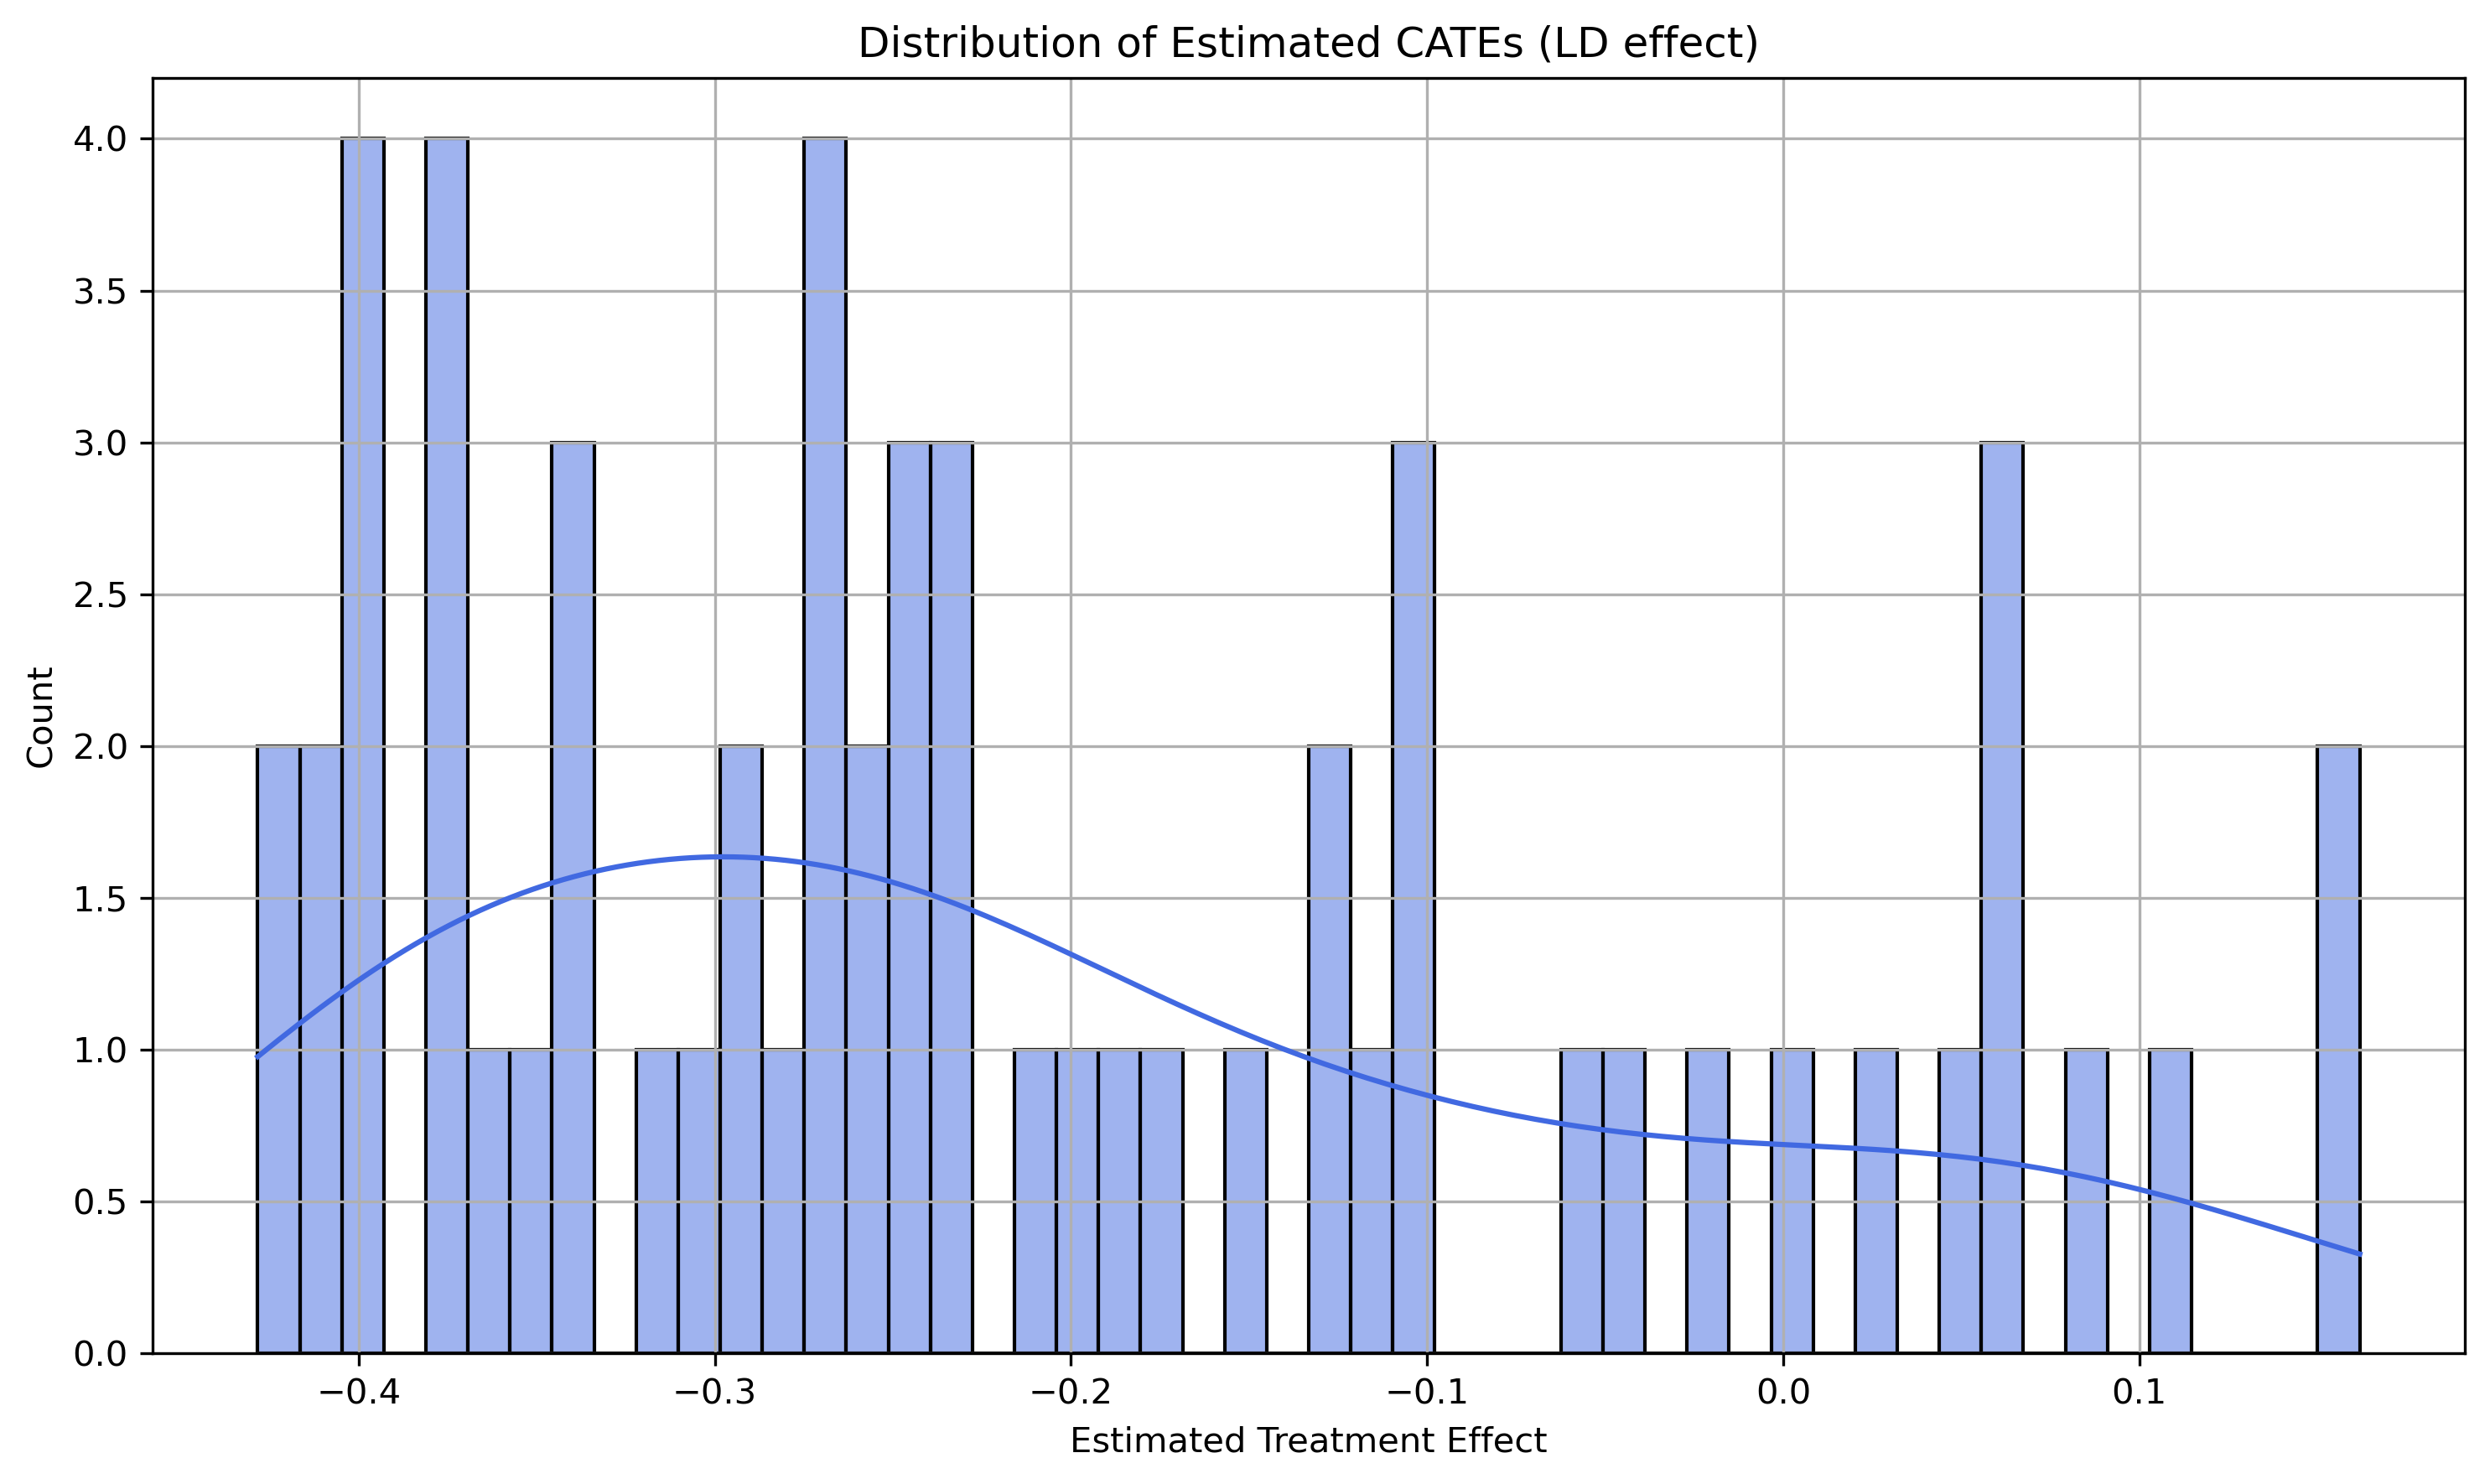

In [1]:
import os
from modules.preprocess import load_and_clean_data, prepare_variables 
from modules.dml import train_causal_forest, evaluate_ate, plot_cates, export_cate_results, learn_policy, learn_policy_forest, save_model, get_feature_importances
from sklearn.model_selection import train_test_split

df = load_and_clean_data("ed.csv", ed_daily_path="ed_daily.csv")
Outcome = 'mrs_full'
X, Y, T, feature_names = prepare_variables(df, Outcome)

X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(X, T, Y, test_size=0.2, random_state=42)

cf_model = train_causal_forest(X_train, Y_train, T_train)
results = evaluate_ate(cf_model, X_test)

print(f"\n📊 ATE Estimate: {results['ate']:.4f}")
print(f"📏 95% CI: ({results['ci'][0]:.4f}, {results['ci'][1]:.4f})")
print(f"📉 SE: {results['se']:.4f}")
print(f"🧪 P-value: {results['pval']:.4f}")

cates = cf_model.effect(X_test)
plot_cates(cates)


'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



📊 ATE Estimate: 0.0110
📏 95% CI: (-0.5904, 0.6124)
📉 SE: 0.3069
🧪 P-value: 0.9714


'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


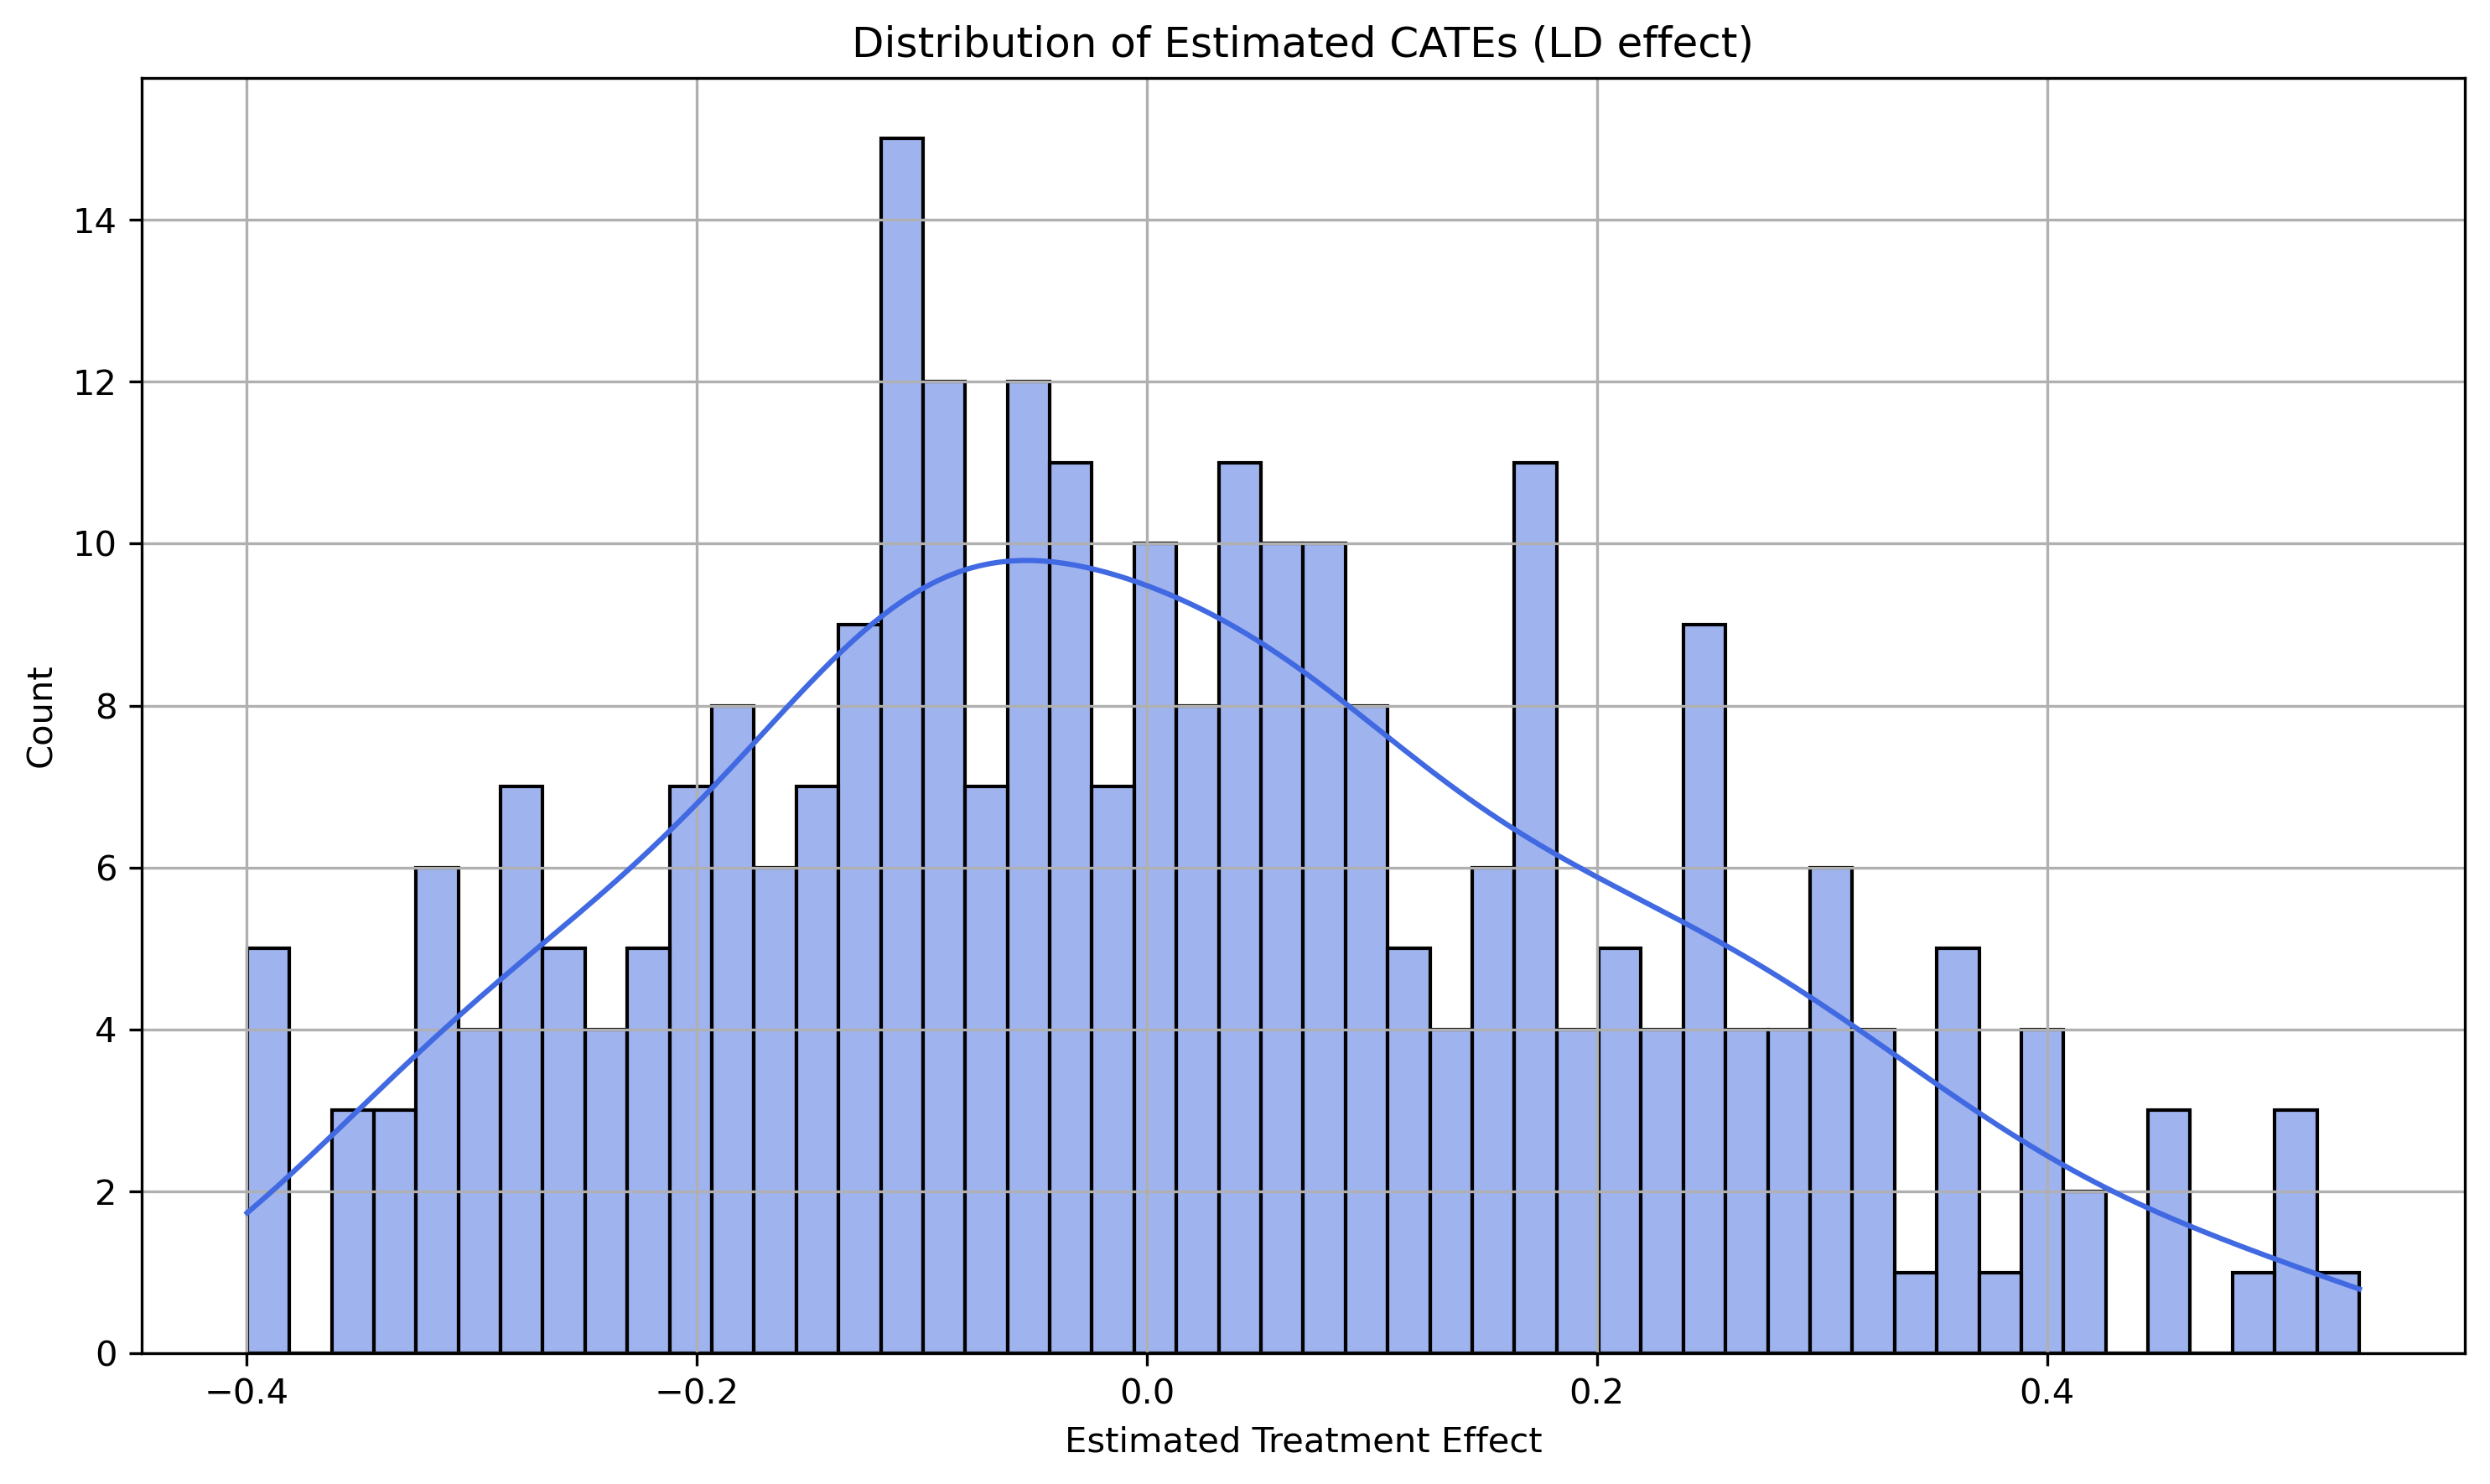

Exported all 287 patients' CATEs to cate_results\cate_results_mrs_full.csv
Model saved to models/cf_model_mrs_full.joblib


In [2]:
df = load_and_clean_data("ed.csv", ed_daily_path="ed_daily.csv")
X, Y, T, feature_names = prepare_variables(df, Outcome)

cf_model = train_causal_forest(X, Y, T)
results = evaluate_ate(cf_model, X)

print(f"\n📊 ATE Estimate: {results['ate']:.4f}")
print(f"📏 95% CI: ({results['ci'][0]:.4f}, {results['ci'][1]:.4f})")
print(f"📉 SE: {results['se']:.4f}")
print(f"🧪 P-value: {results['pval']:.4f}")

cates = cf_model.effect(X)
plot_cates(cates)
export_cate_results(X, cates, Y, T, feature_names, outcome_name=Outcome)
save_model(cf_model, path=f"models/cf_model_{Outcome}.joblib")

In [3]:
get_feature_importances(cf_model, feature_names)


Feature Importances (CausalForestDML):
balance_mean: 0.1436
rr_dia_mean: 0.1178
age: 0.1028
hb_mean: 0.0695
ld_mean: 0.0684
icp_7am_mean: 0.0614
aneurysm_size: 0.0555
bmi: 0.0532
rr_syst_mean: 0.0525
icp_high_mean: 0.0510
evd_mean: 0.0507
rr_map_mean: 0.0473
wfns: 0.0283
hh: 0.0195
ct_ich: 0.0156
sex: 0.0115
mg: 0.0113
aneurysm_trt: 0.0094
ct_modfisher: 0.0086
aneurysm_no: 0.0067
aphasia_adm: 0.0064
paresis_adm: 0.0052
ct_ivh: 0.0033
aneurysm_circulation: 0.0006
statin: 0.0002
sedation_adm: 0.0000
mrs_adm: 0.0000
nimodipine: 0.0000


balance_mean            0.143577
rr_dia_mean             0.117752
age                     0.102789
hb_mean                 0.069454
ld_mean                 0.068412
icp_7am_mean            0.061381
aneurysm_size           0.055519
bmi                     0.053212
rr_syst_mean            0.052453
icp_high_mean           0.050960
evd_mean                0.050665
rr_map_mean             0.047295
wfns                    0.028265
hh                      0.019532
ct_ich                  0.015563
sex                     0.011530
mg                      0.011315
aneurysm_trt            0.009365
ct_modfisher            0.008577
aneurysm_no             0.006729
aphasia_adm             0.006363
paresis_adm             0.005229
ct_ivh                  0.003279
aneurysm_circulation    0.000590
statin                  0.000192
sedation_adm            0.000000
mrs_adm                 0.000000
nimodipine              0.000000
dtype: float64

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
Glyph 129504 (\N{BRAIN}) missing from current font.


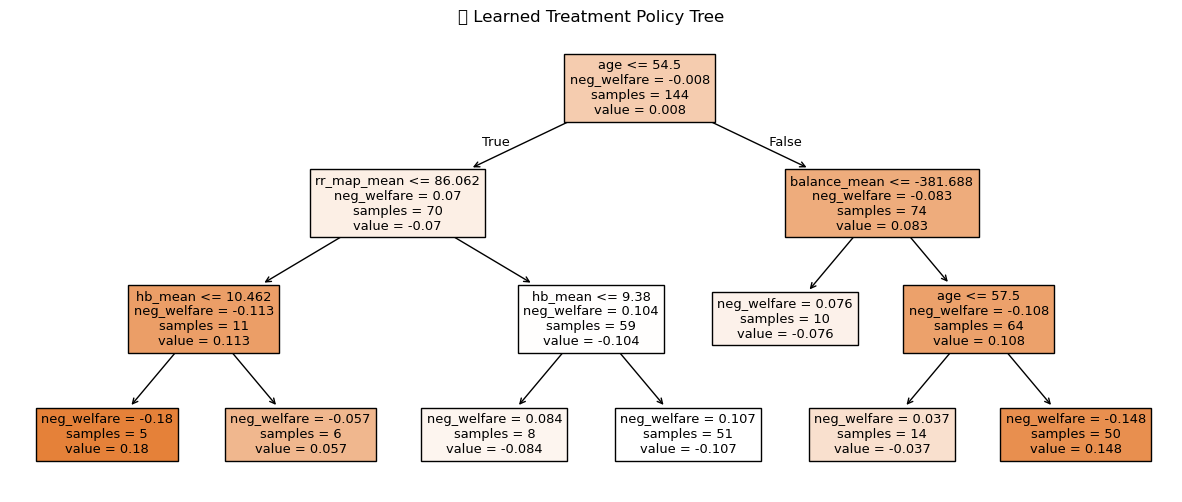

📋 Policy recommendations:
 [0 0 0 0 0 0 0 0 0 0]


In [4]:
policy_tree = learn_policy(cf_model, X)
import matplotlib.pyplot as plt

# Visualize
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 6))
plot_tree(policy_tree, feature_names=feature_names, filled=True)
plt.title("🧠 Learned Treatment Policy Tree")
plt.show()

# Binary treatment recommendations
policy_recs = policy_tree.predict(X)
print("📋 Policy recommendations:\n", policy_recs[:10])



🔬 Subgroup CATEs: aneurysm_trt
Group 1 = clipping → Mean CATE: 0.0323
Group 2 = coiling → Mean CATE: -0.0093
ΔCATE (clipping - coiling) = 0.0416
🧪 P-value: 0.0912




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



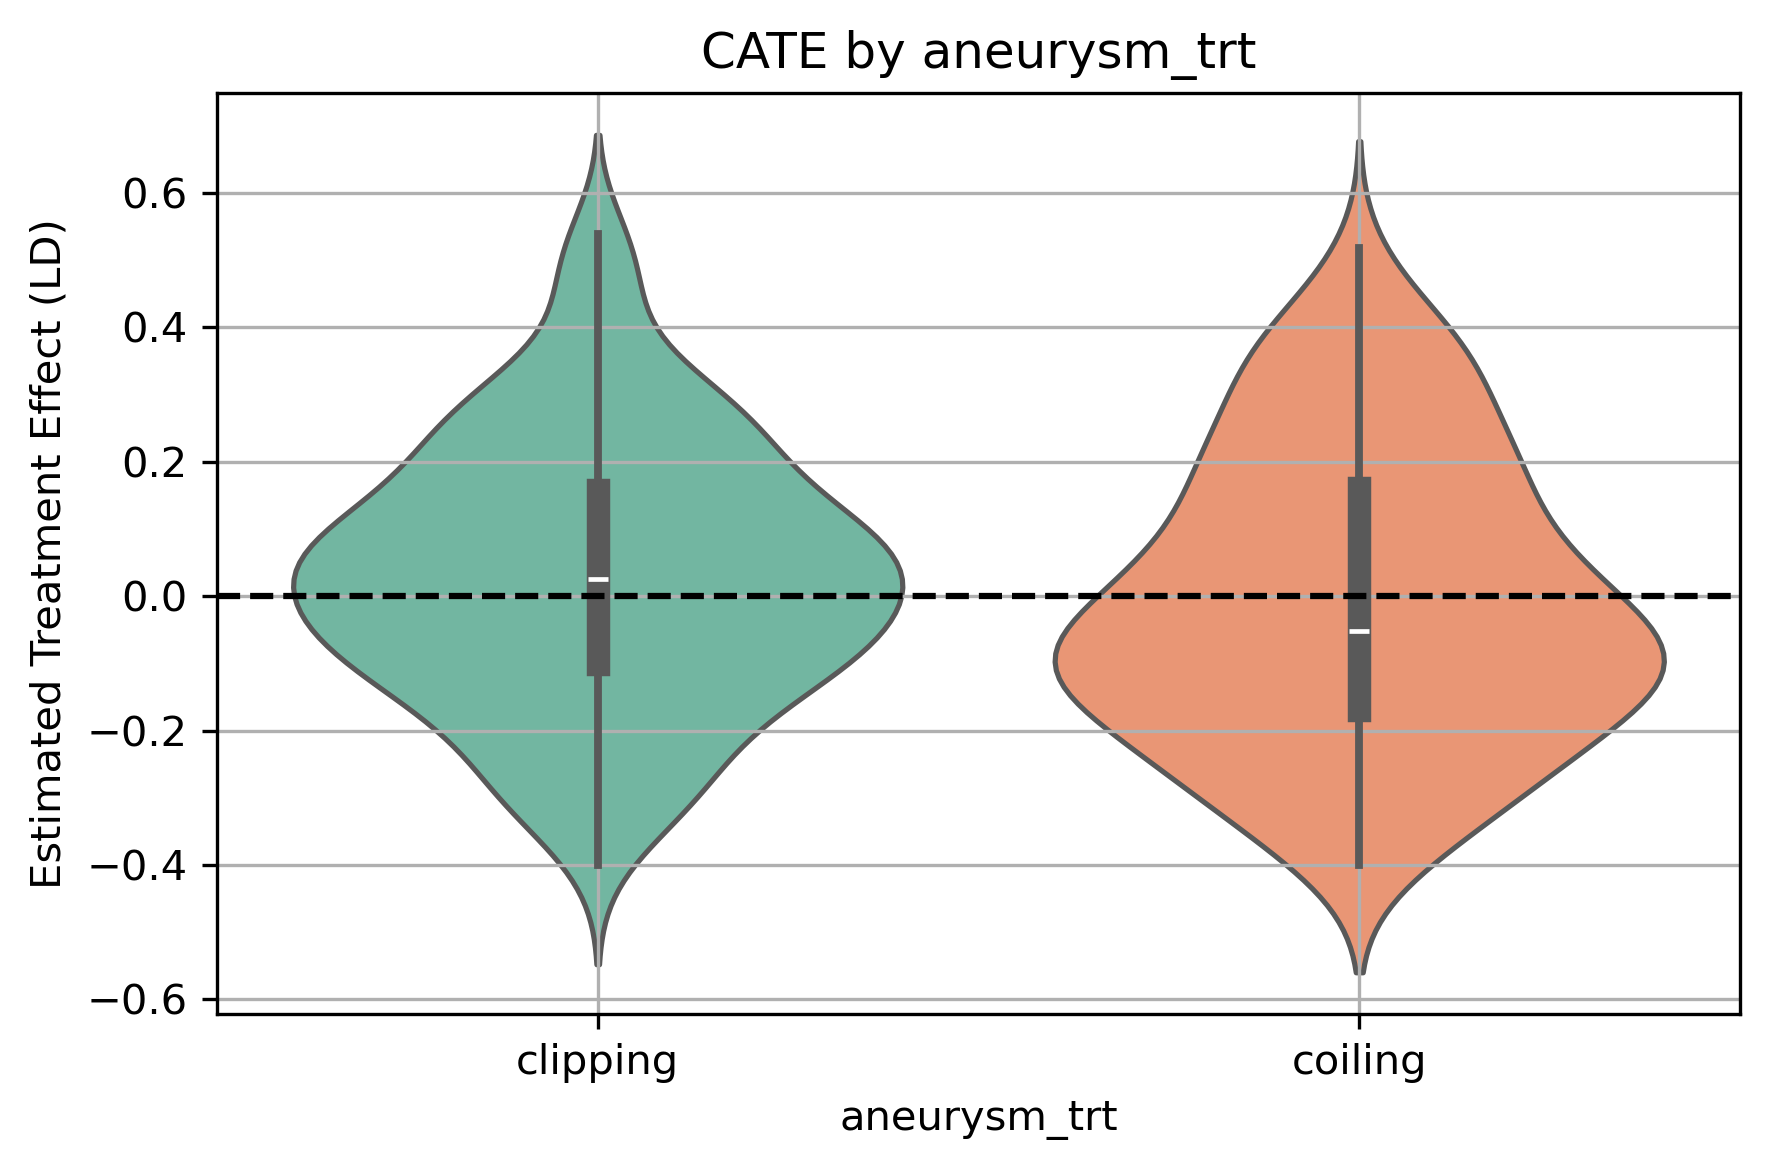


🔬 Subgroup CATEs: aneurysm_circulation
Group 1 = anterior → Mean CATE: 0.0161
Group 2 = posterior → Mean CATE: -0.0170
ΔCATE (anterior - posterior) = 0.0331
🧪 P-value: 0.3278




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



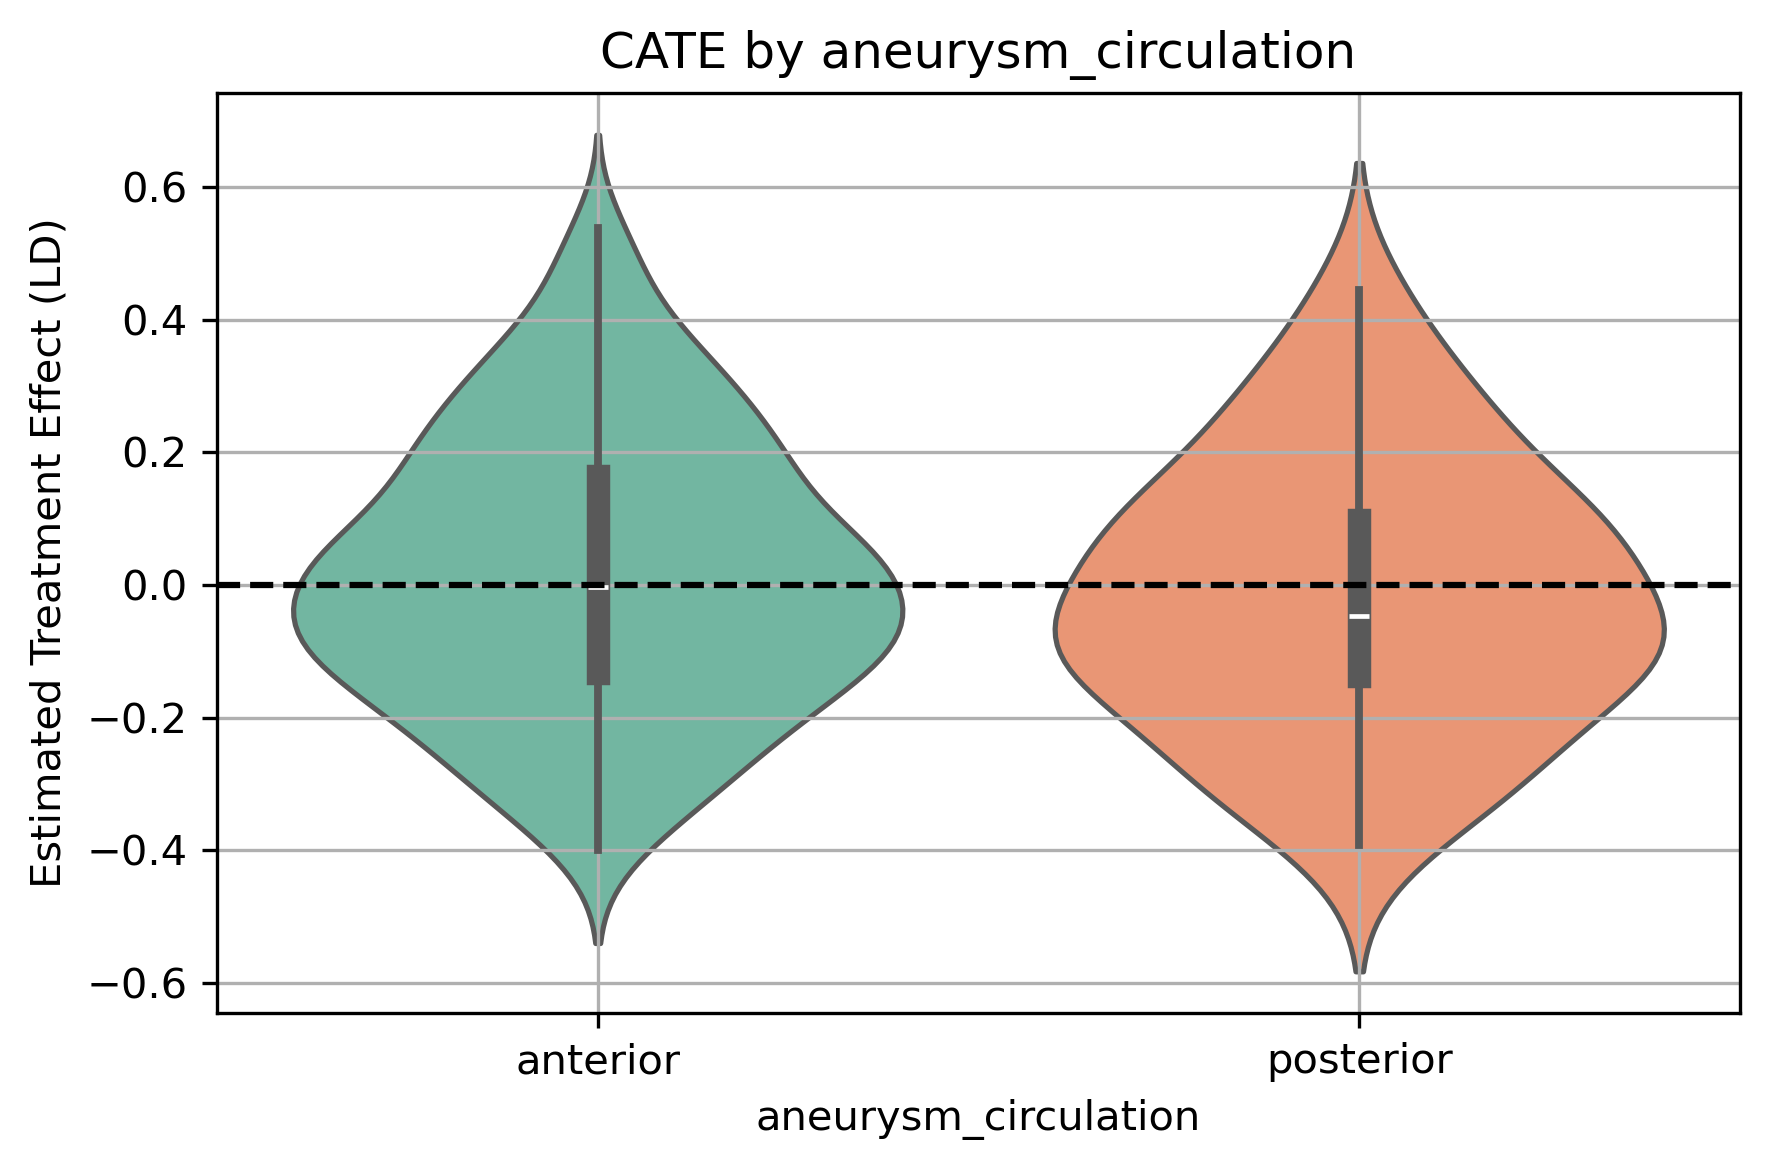


🔬 Subgroup CATEs: paresis_adm
Group 1 = yes → Mean CATE: 0.0787
Group 2 = no → Mean CATE: -0.0185
ΔCATE (yes - no) = 0.0972
🧪 P-value: 0.0002




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



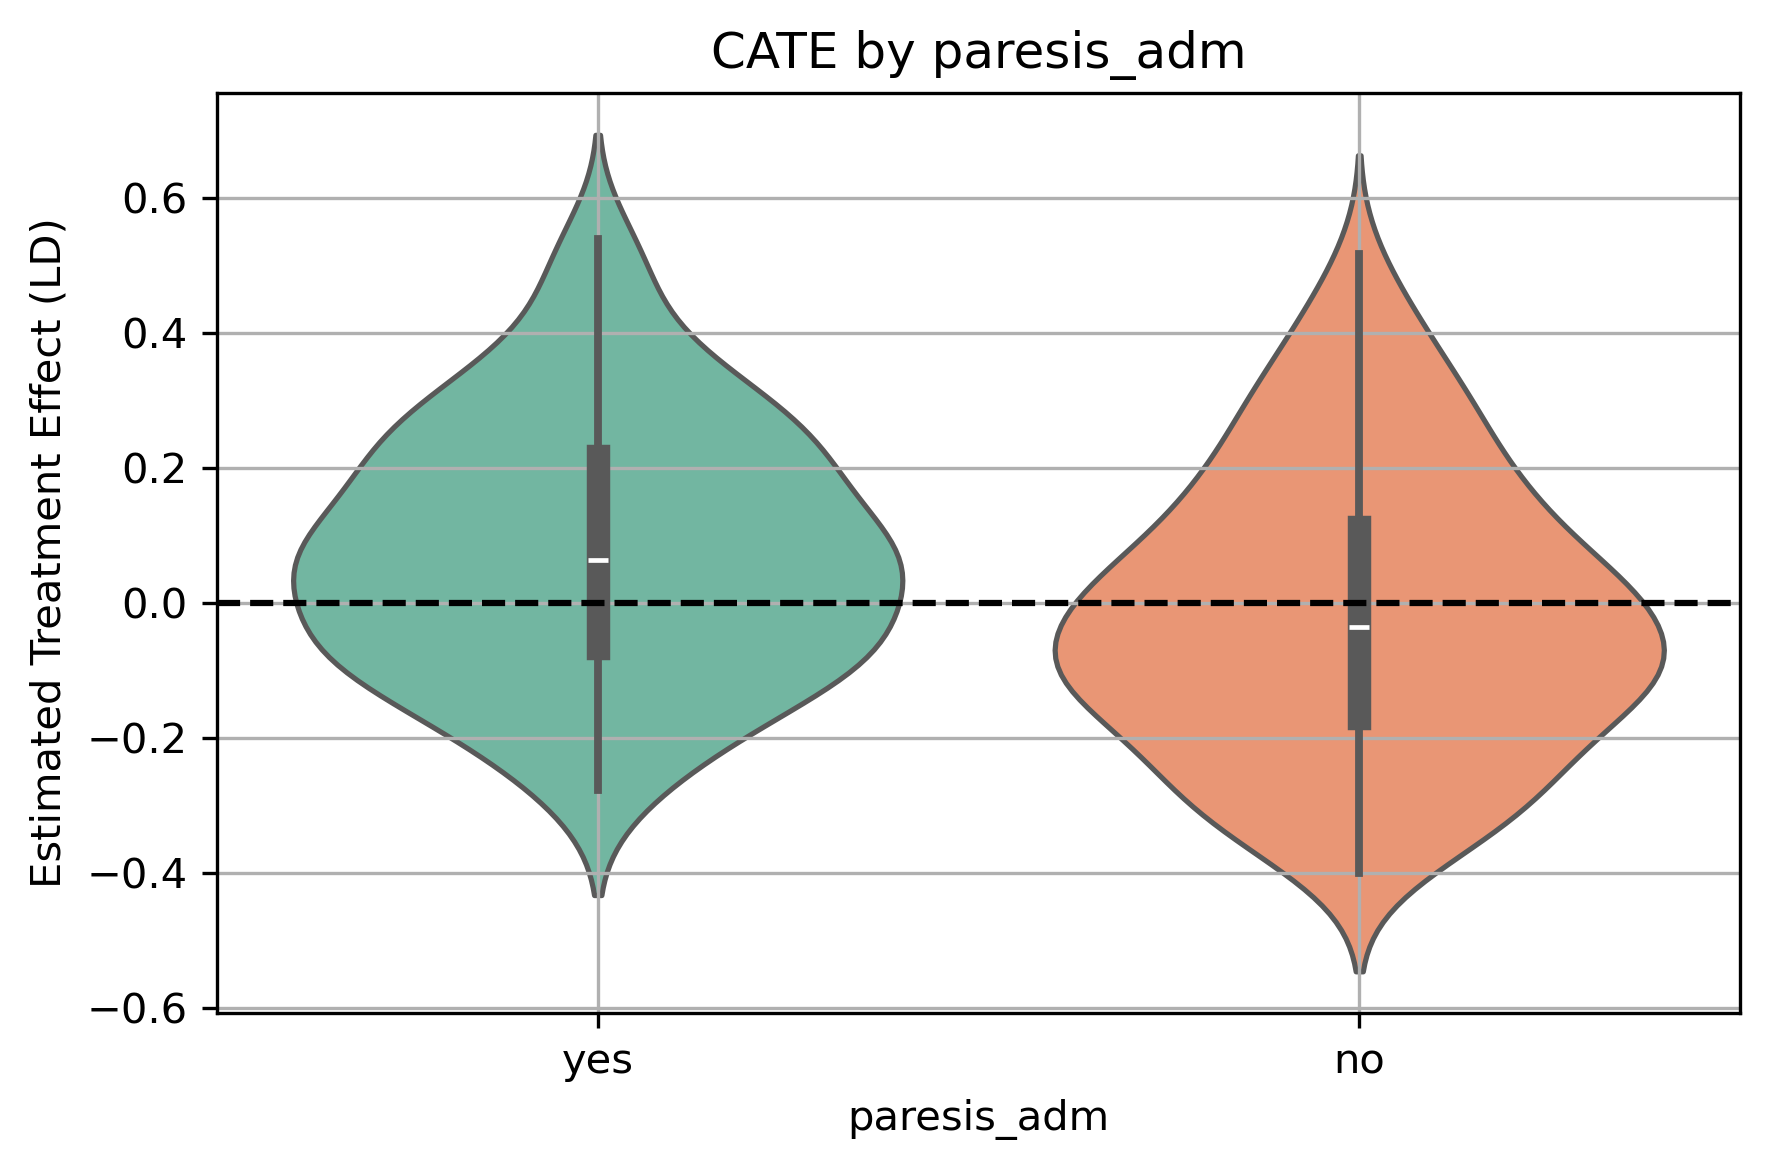


🔬 Subgroup CATEs: aphasia_adm
Group 1 = yes → Mean CATE: 0.0778
Group 2 = no → Mean CATE: -0.0220
ΔCATE (yes - no) = 0.0998
🧪 P-value: 0.0001




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



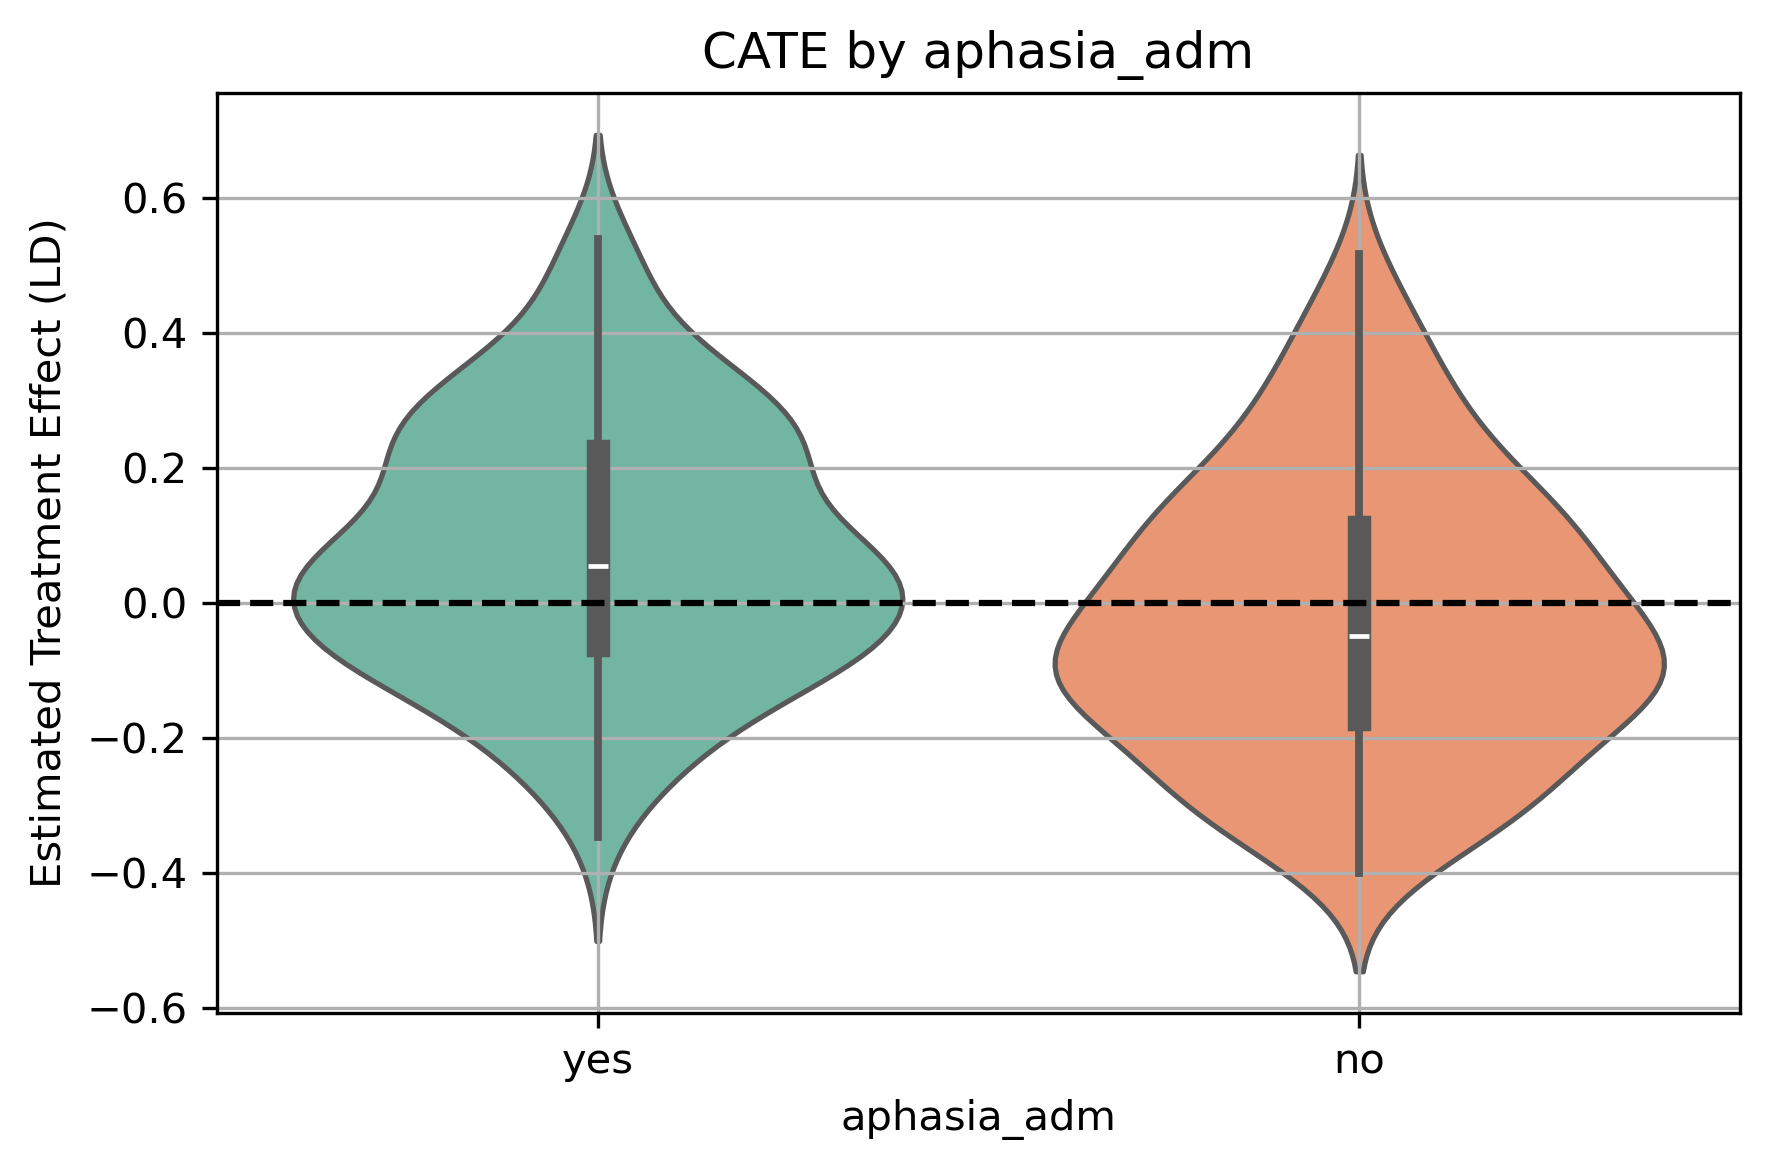


🔬 Subgroup CATEs: nimodipine
Group 1 = yes → Mean CATE: 0.0094
Group 2 = no → Mean CATE: 0.1666
ΔCATE (yes - no) = -0.1573
🧪 P-value: 0.3827




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



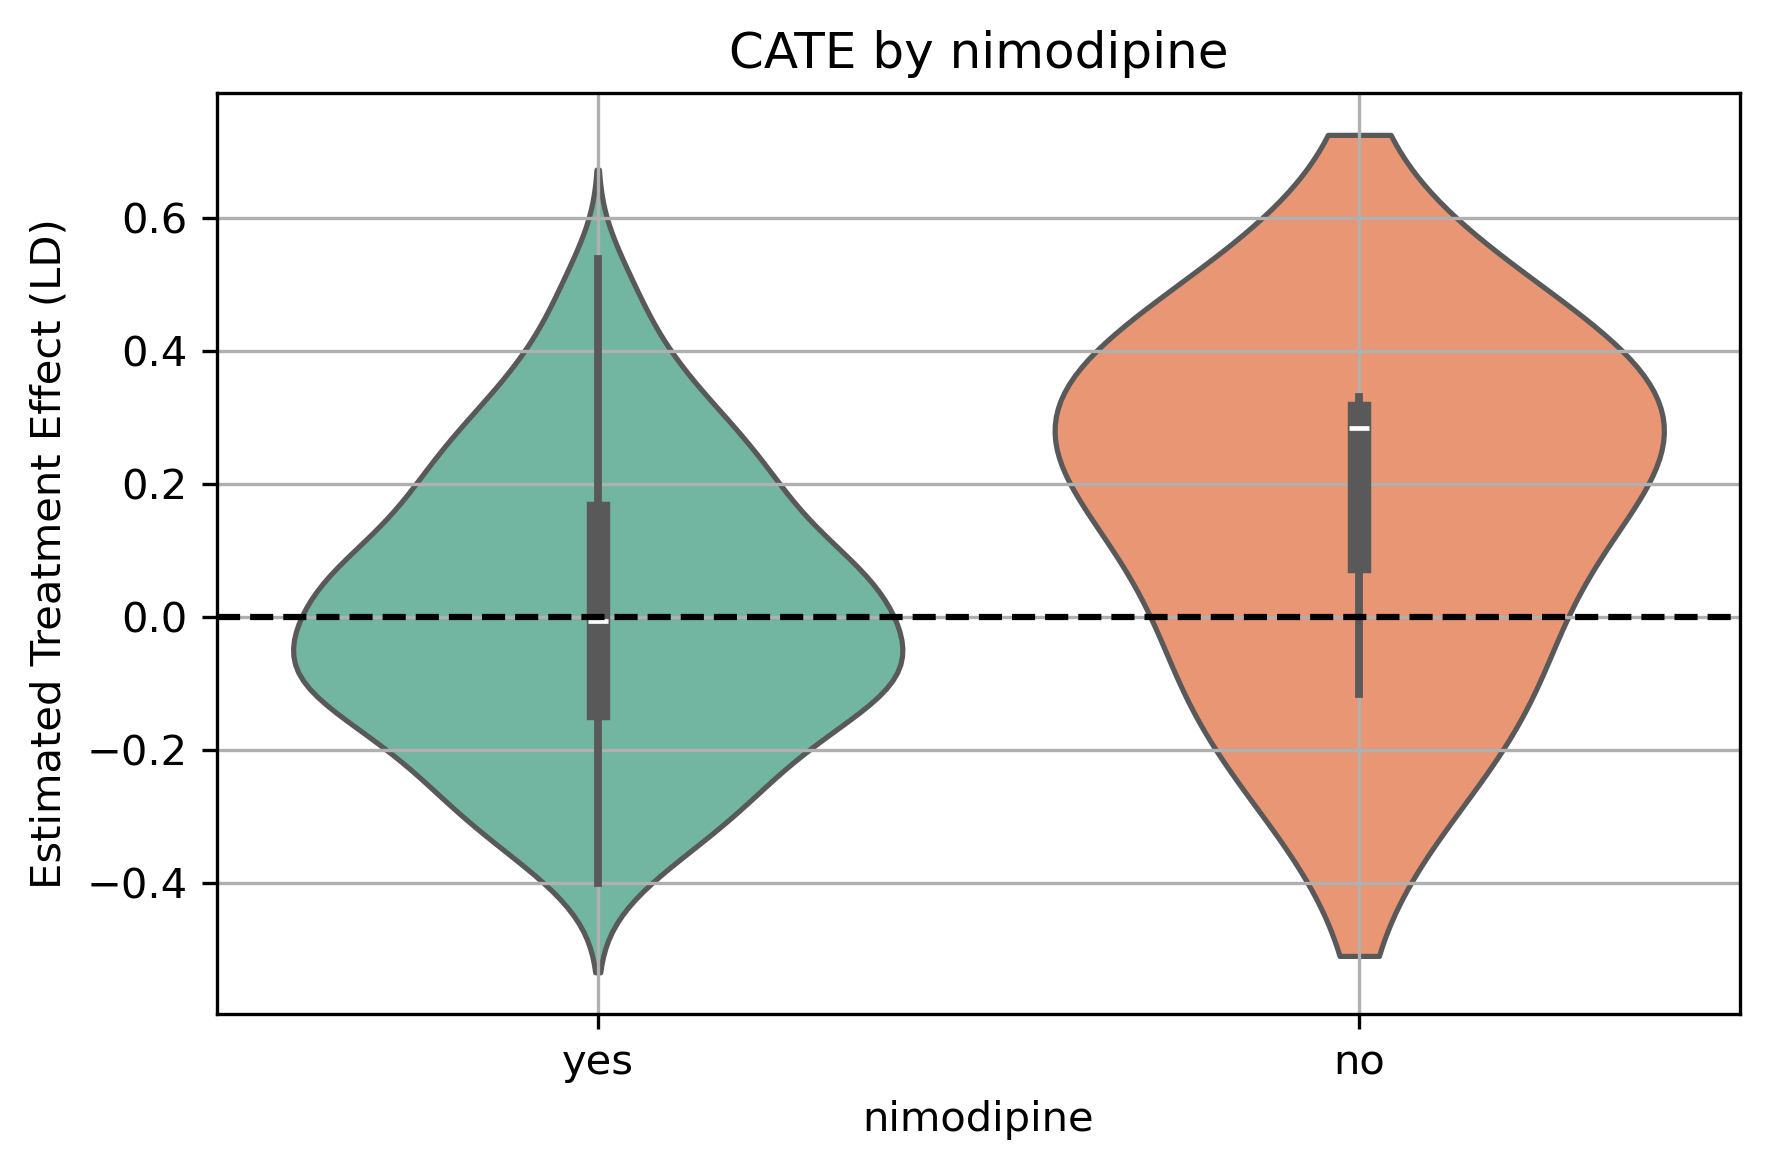


🔬 Subgroup CATEs: ct_ivh
Group 1 = no → Mean CATE: -0.0718
Group 2 = yes → Mean CATE: 0.0640
ΔCATE (no - yes) = -0.1358
🧪 P-value: 0.0000




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



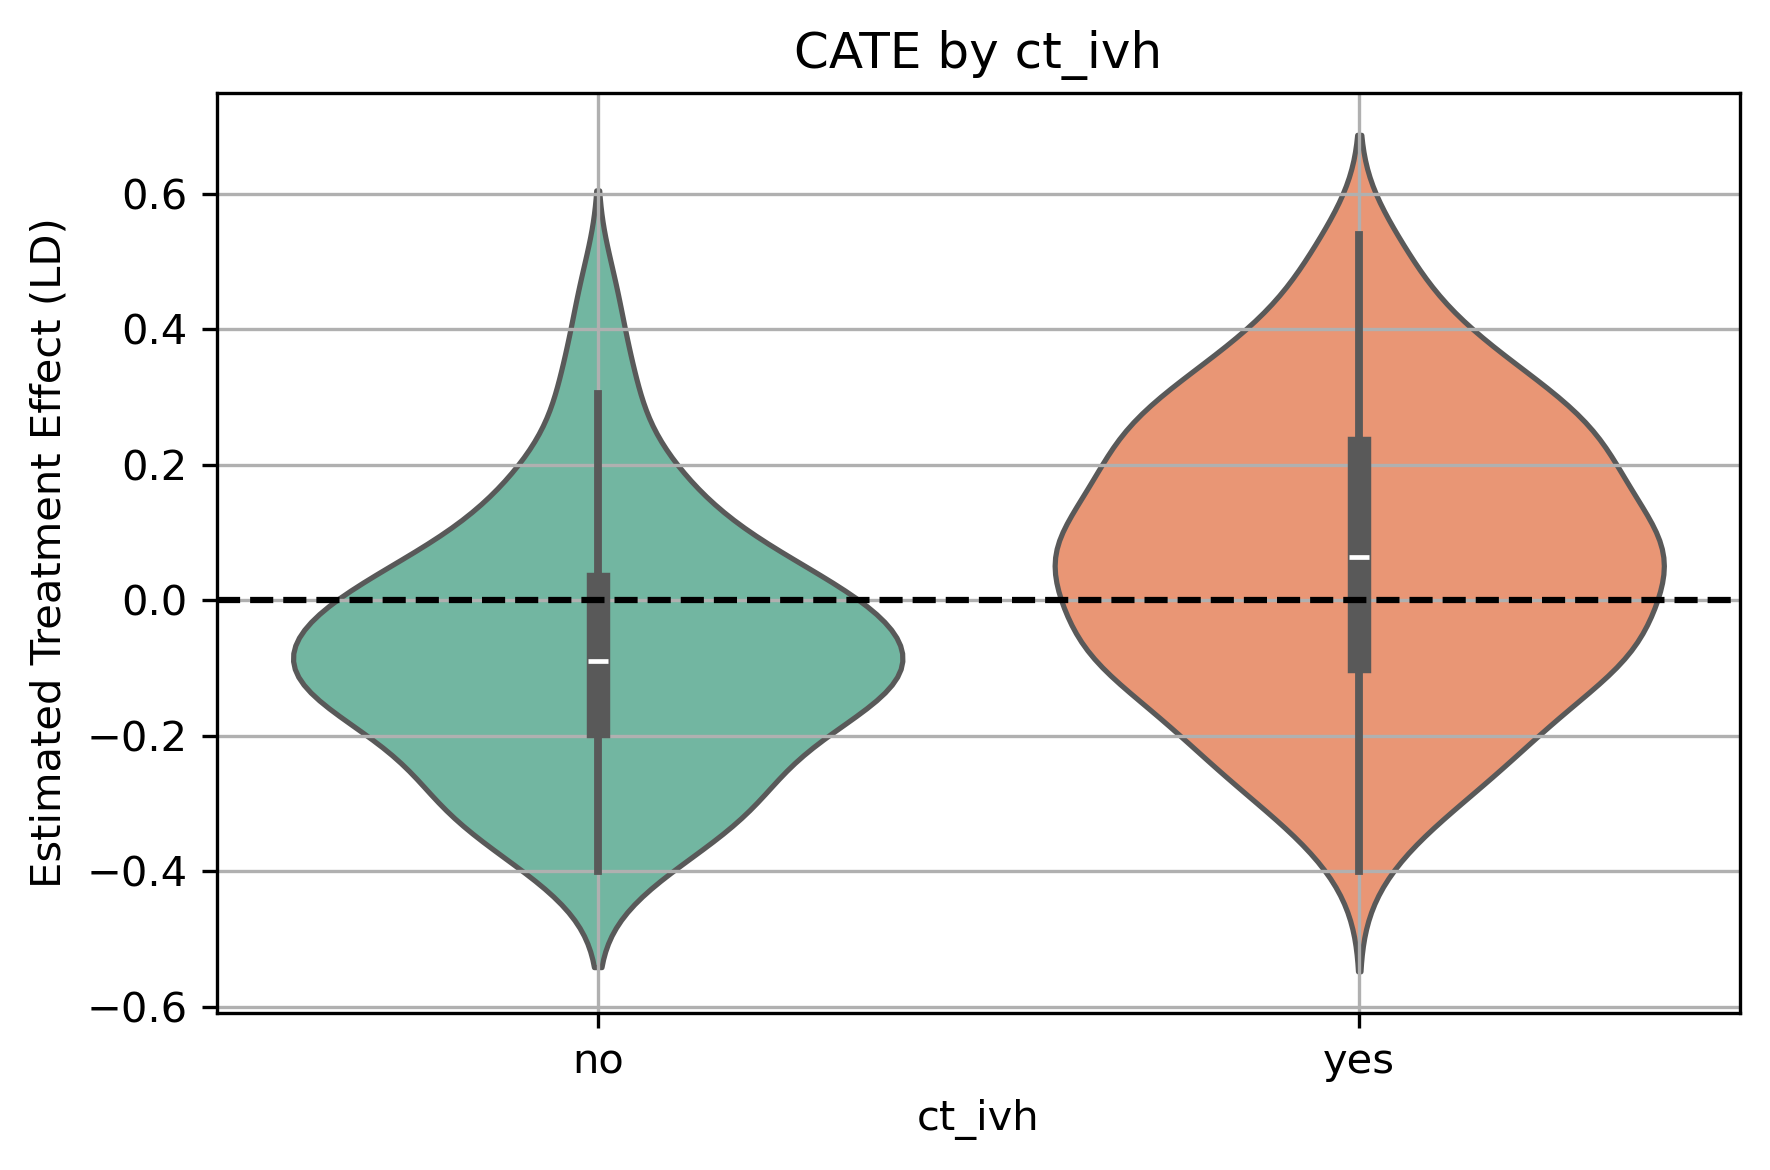


🔬 Subgroup CATEs: ct_ich
Group 1 = no → Mean CATE: -0.0363
Group 2 = yes → Mean CATE: 0.0918
ΔCATE (no - yes) = -0.1281
🧪 P-value: 0.0000




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



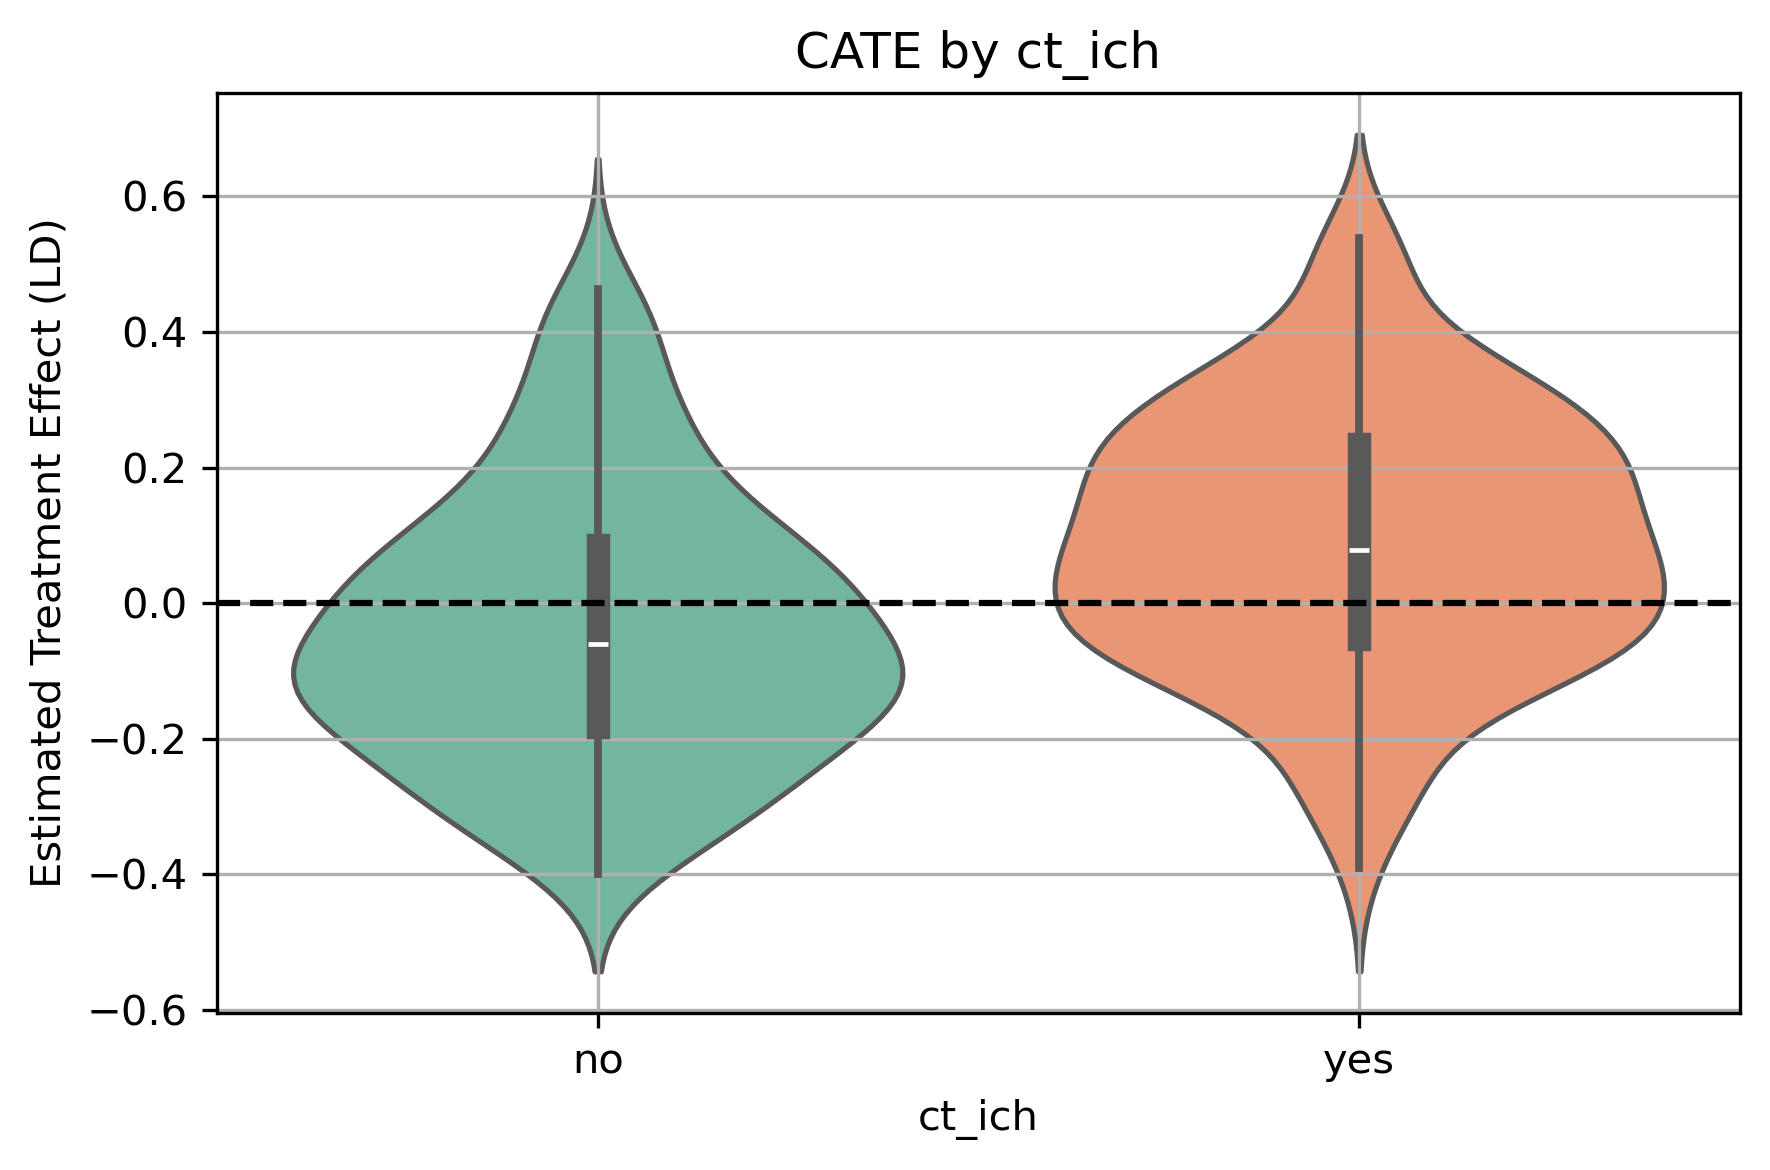

In [5]:
from modules.analysis import analyze_binary_subgroup_cates, plot_cate_vs_feature, analyze_ordinal_features, run_doubleml_analysis
import pandas as pd

binary_features = ['aneurysm_trt', 'aneurysm_circulation', 'paresis_adm', 'aphasia_adm', 'nimodipine', 'ct_ivh', 'ct_ich']
cate_df = pd.DataFrame(X, columns=feature_names)
cate_df['treatment_effect'] = cates
reverse_maps = {
    'aneurysm_trt': {1: 'coiling', 0: 'clipping'},
    'aneurysm_circulation': {1: 'anterior', 0: 'posterior'},
    'paresis_adm': {1: 'yes', 0: 'no'},
    'aphasia_adm': {1: 'yes', 0: 'no'},
    'nimodipine': {1: 'yes', 0: 'no'},
    'ct_ivh': {1: 'yes', 0: 'no'},
    'ct_ich': {1: 'yes', 0: 'no'},
    'statin': {1: 'yes', 0: 'no'},
    'mg': {1: 'yes', 0: 'no'},
    'infarct_trt': {1: 'yes', 0: 'no'},
}

analyze_binary_subgroup_cates(cate_df, df, cates, binary_features, reverse_maps)


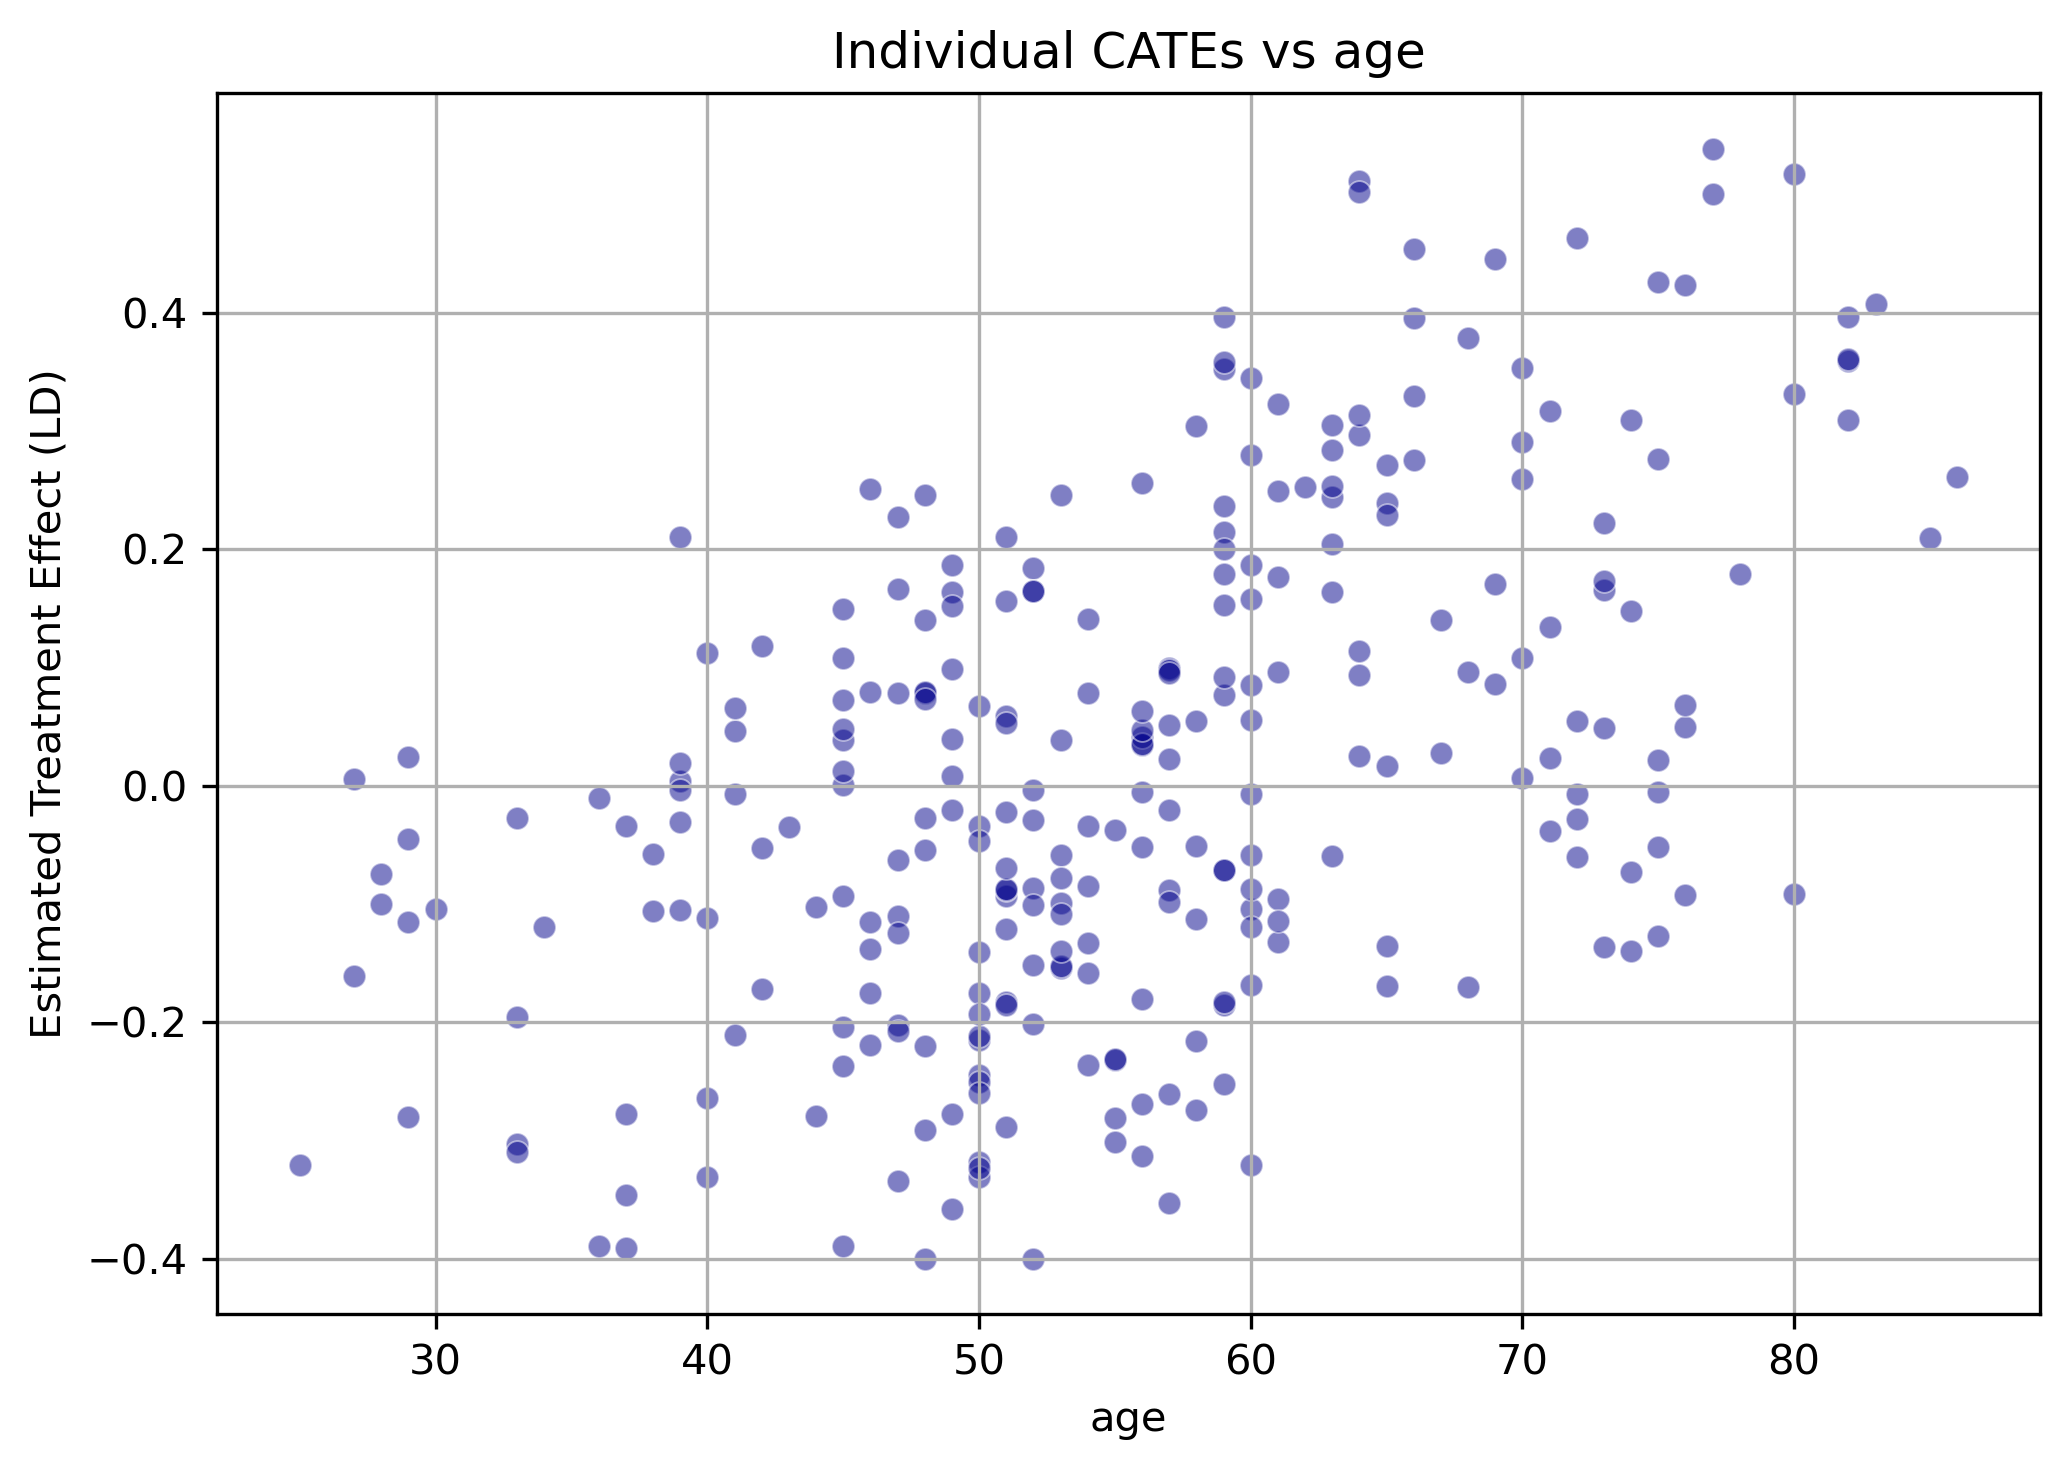

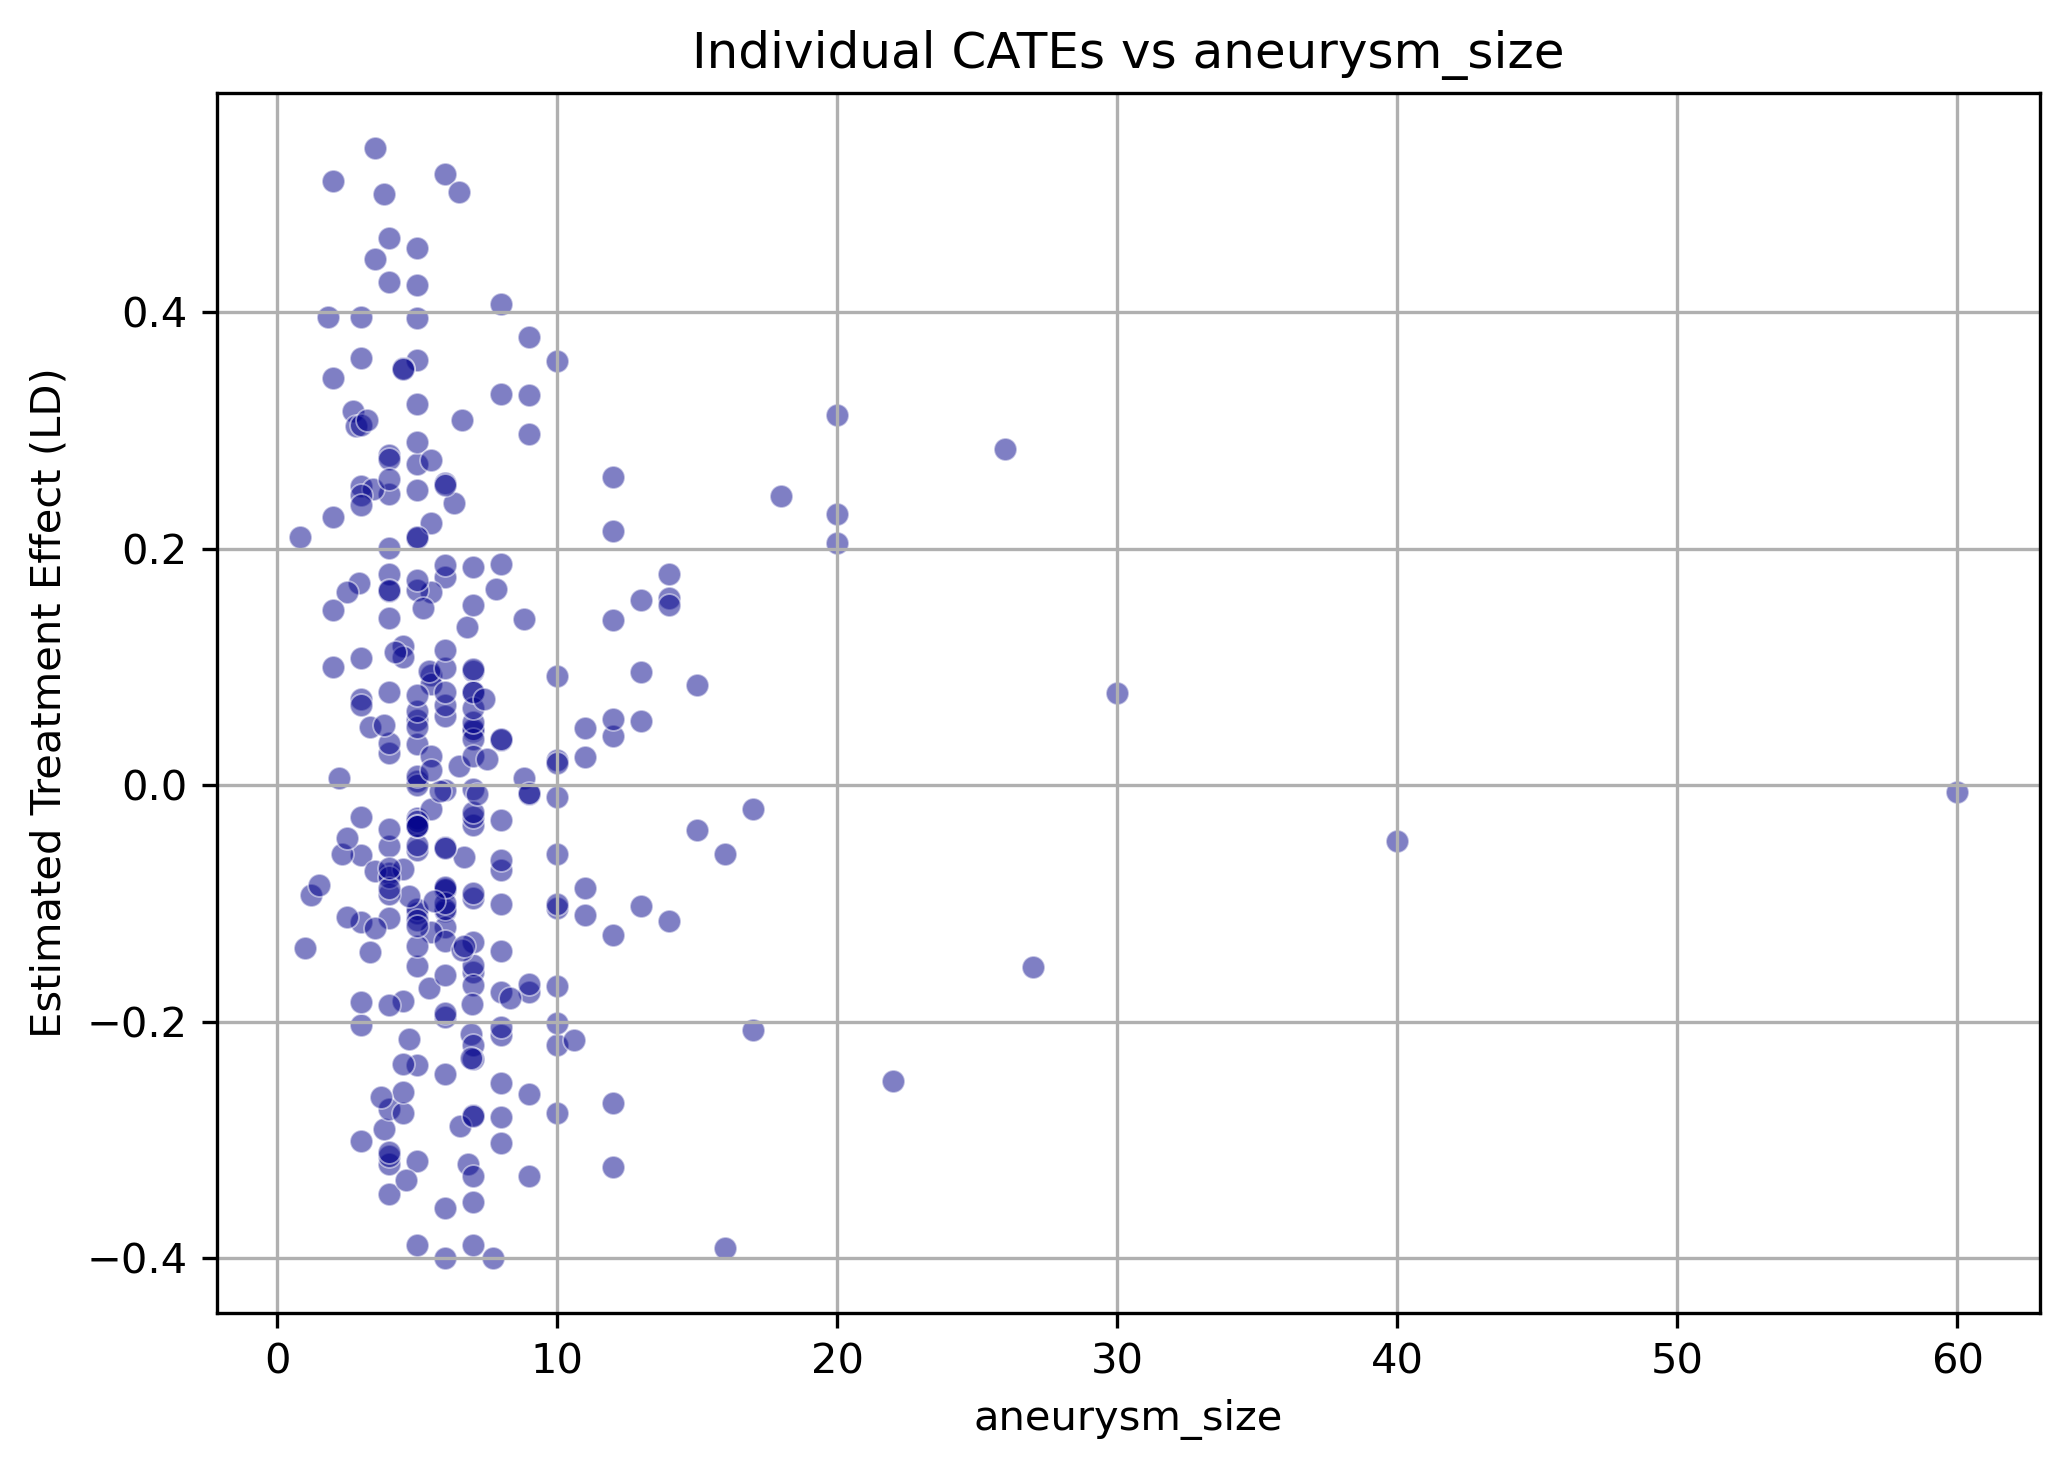

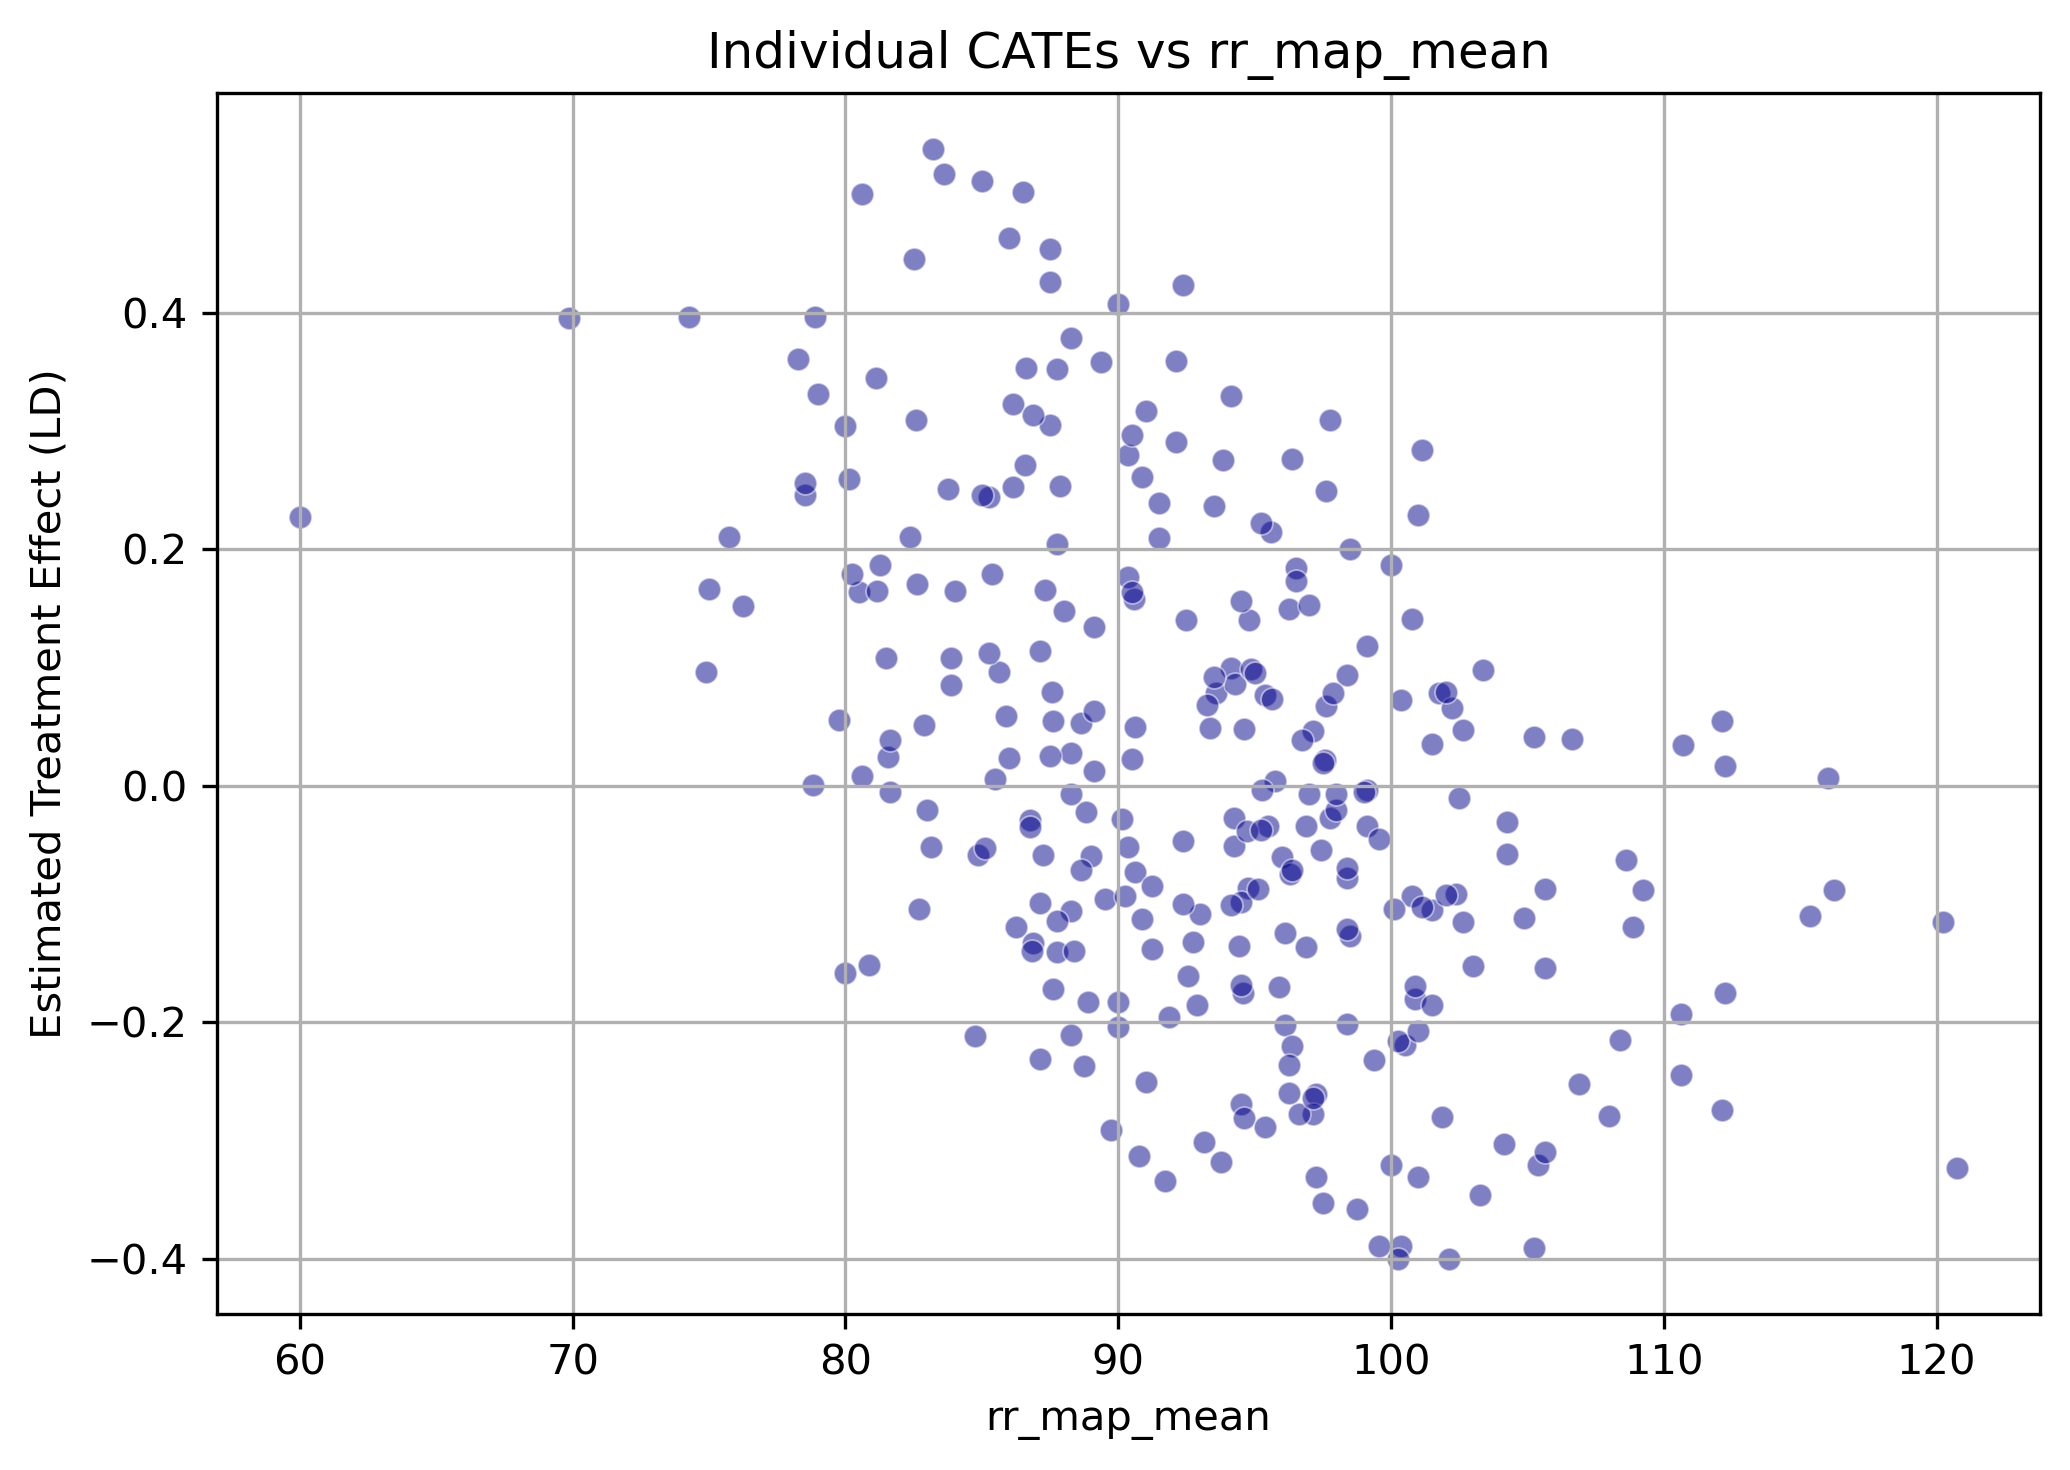

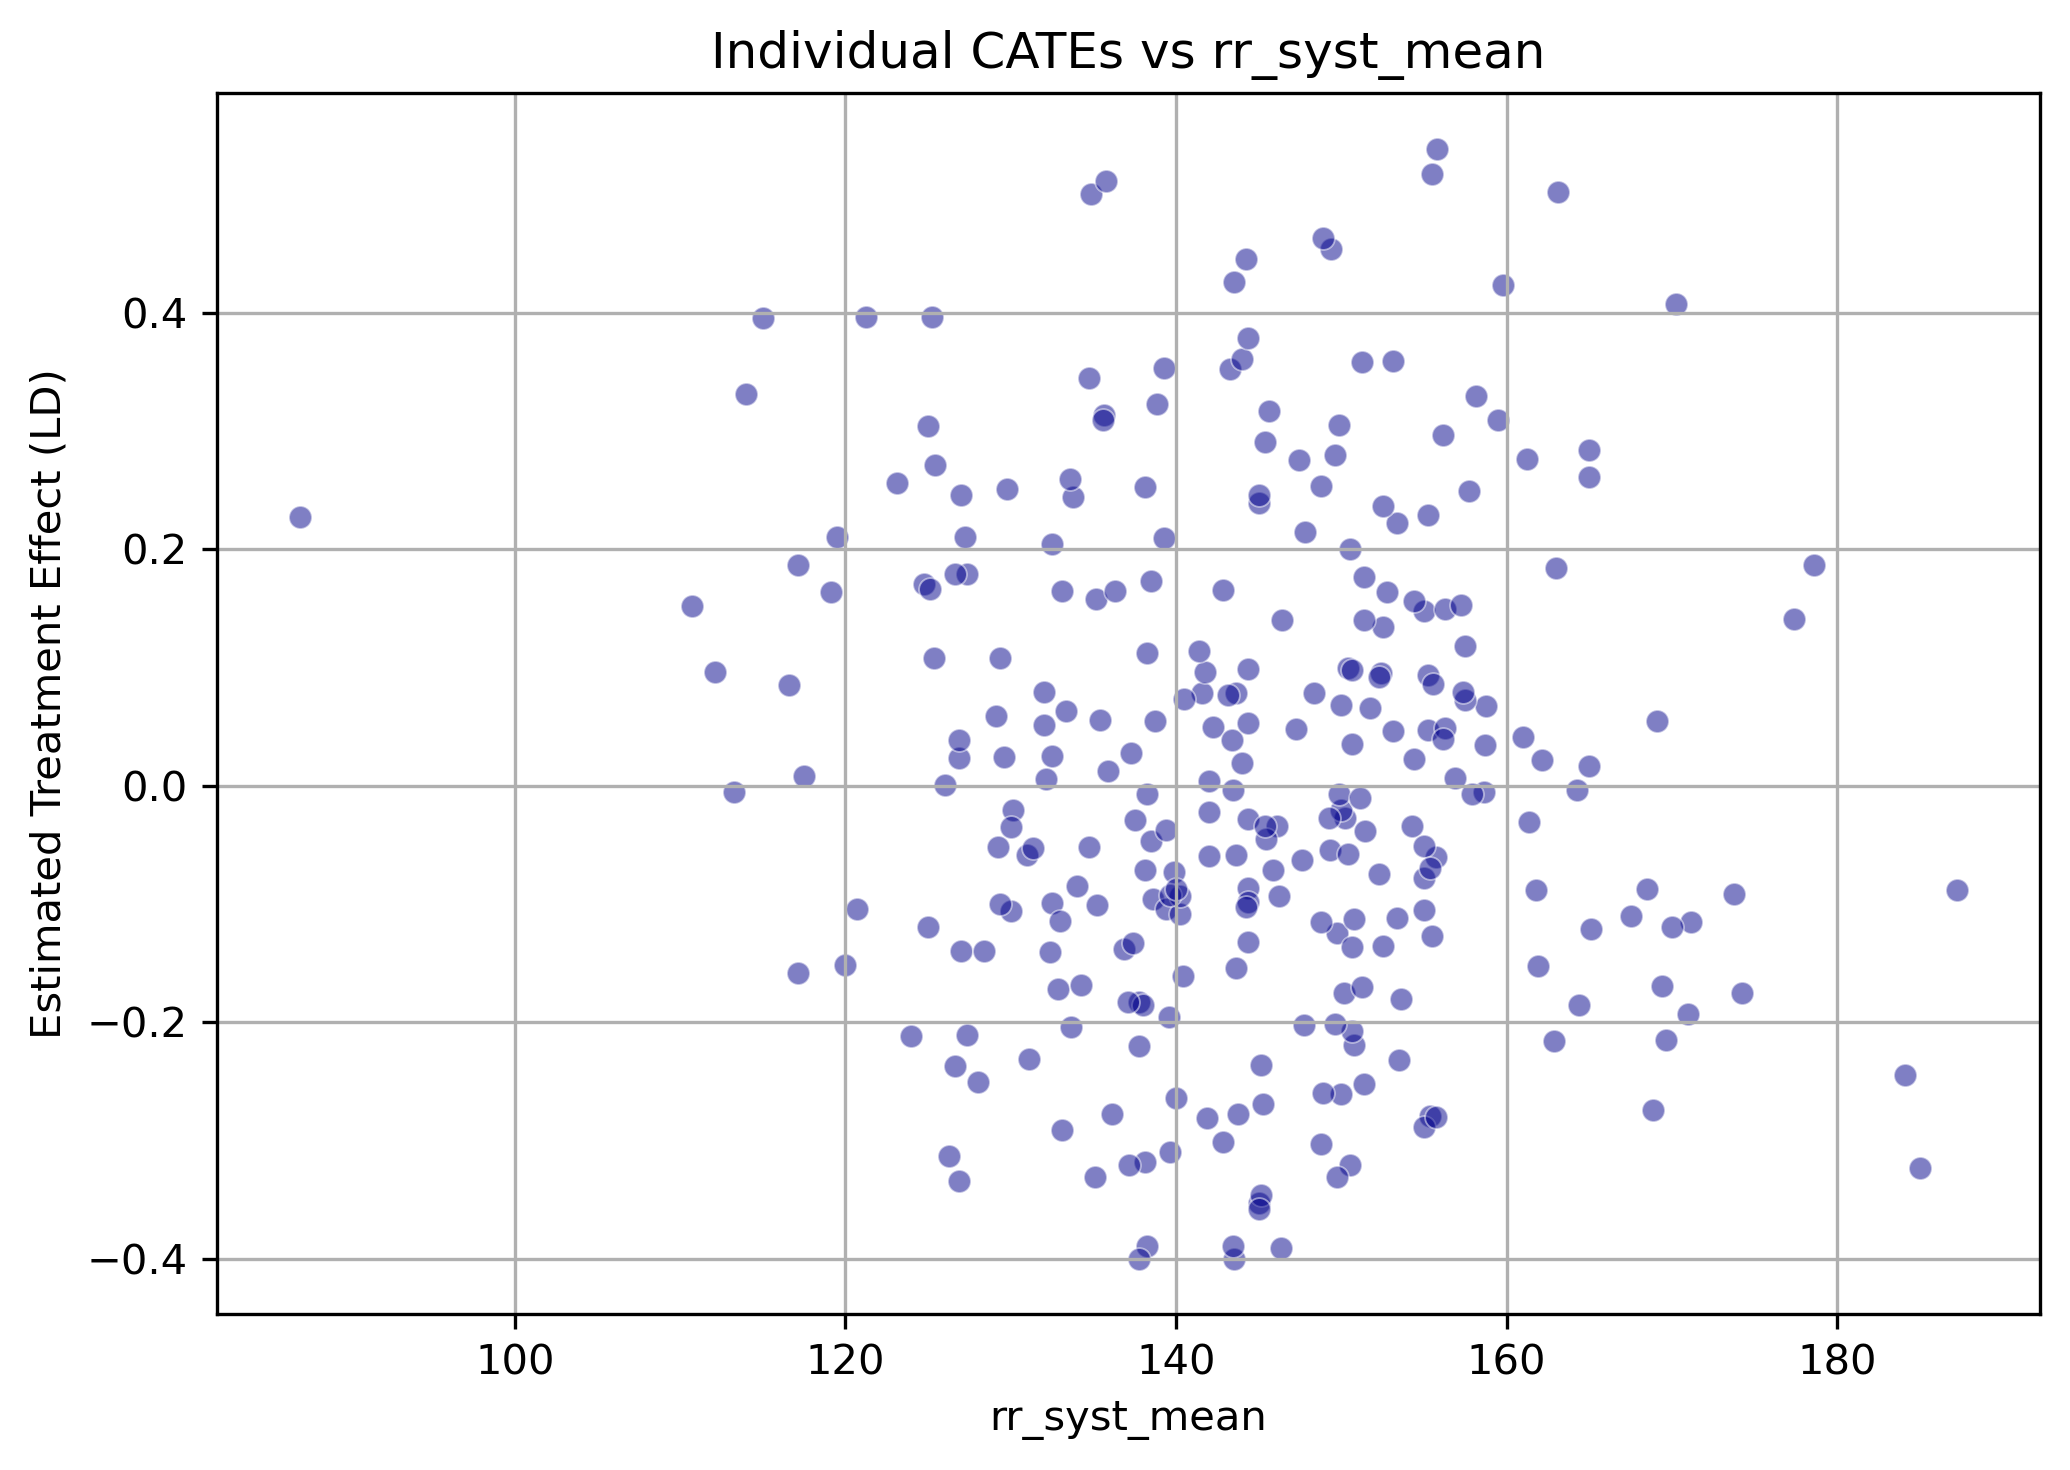

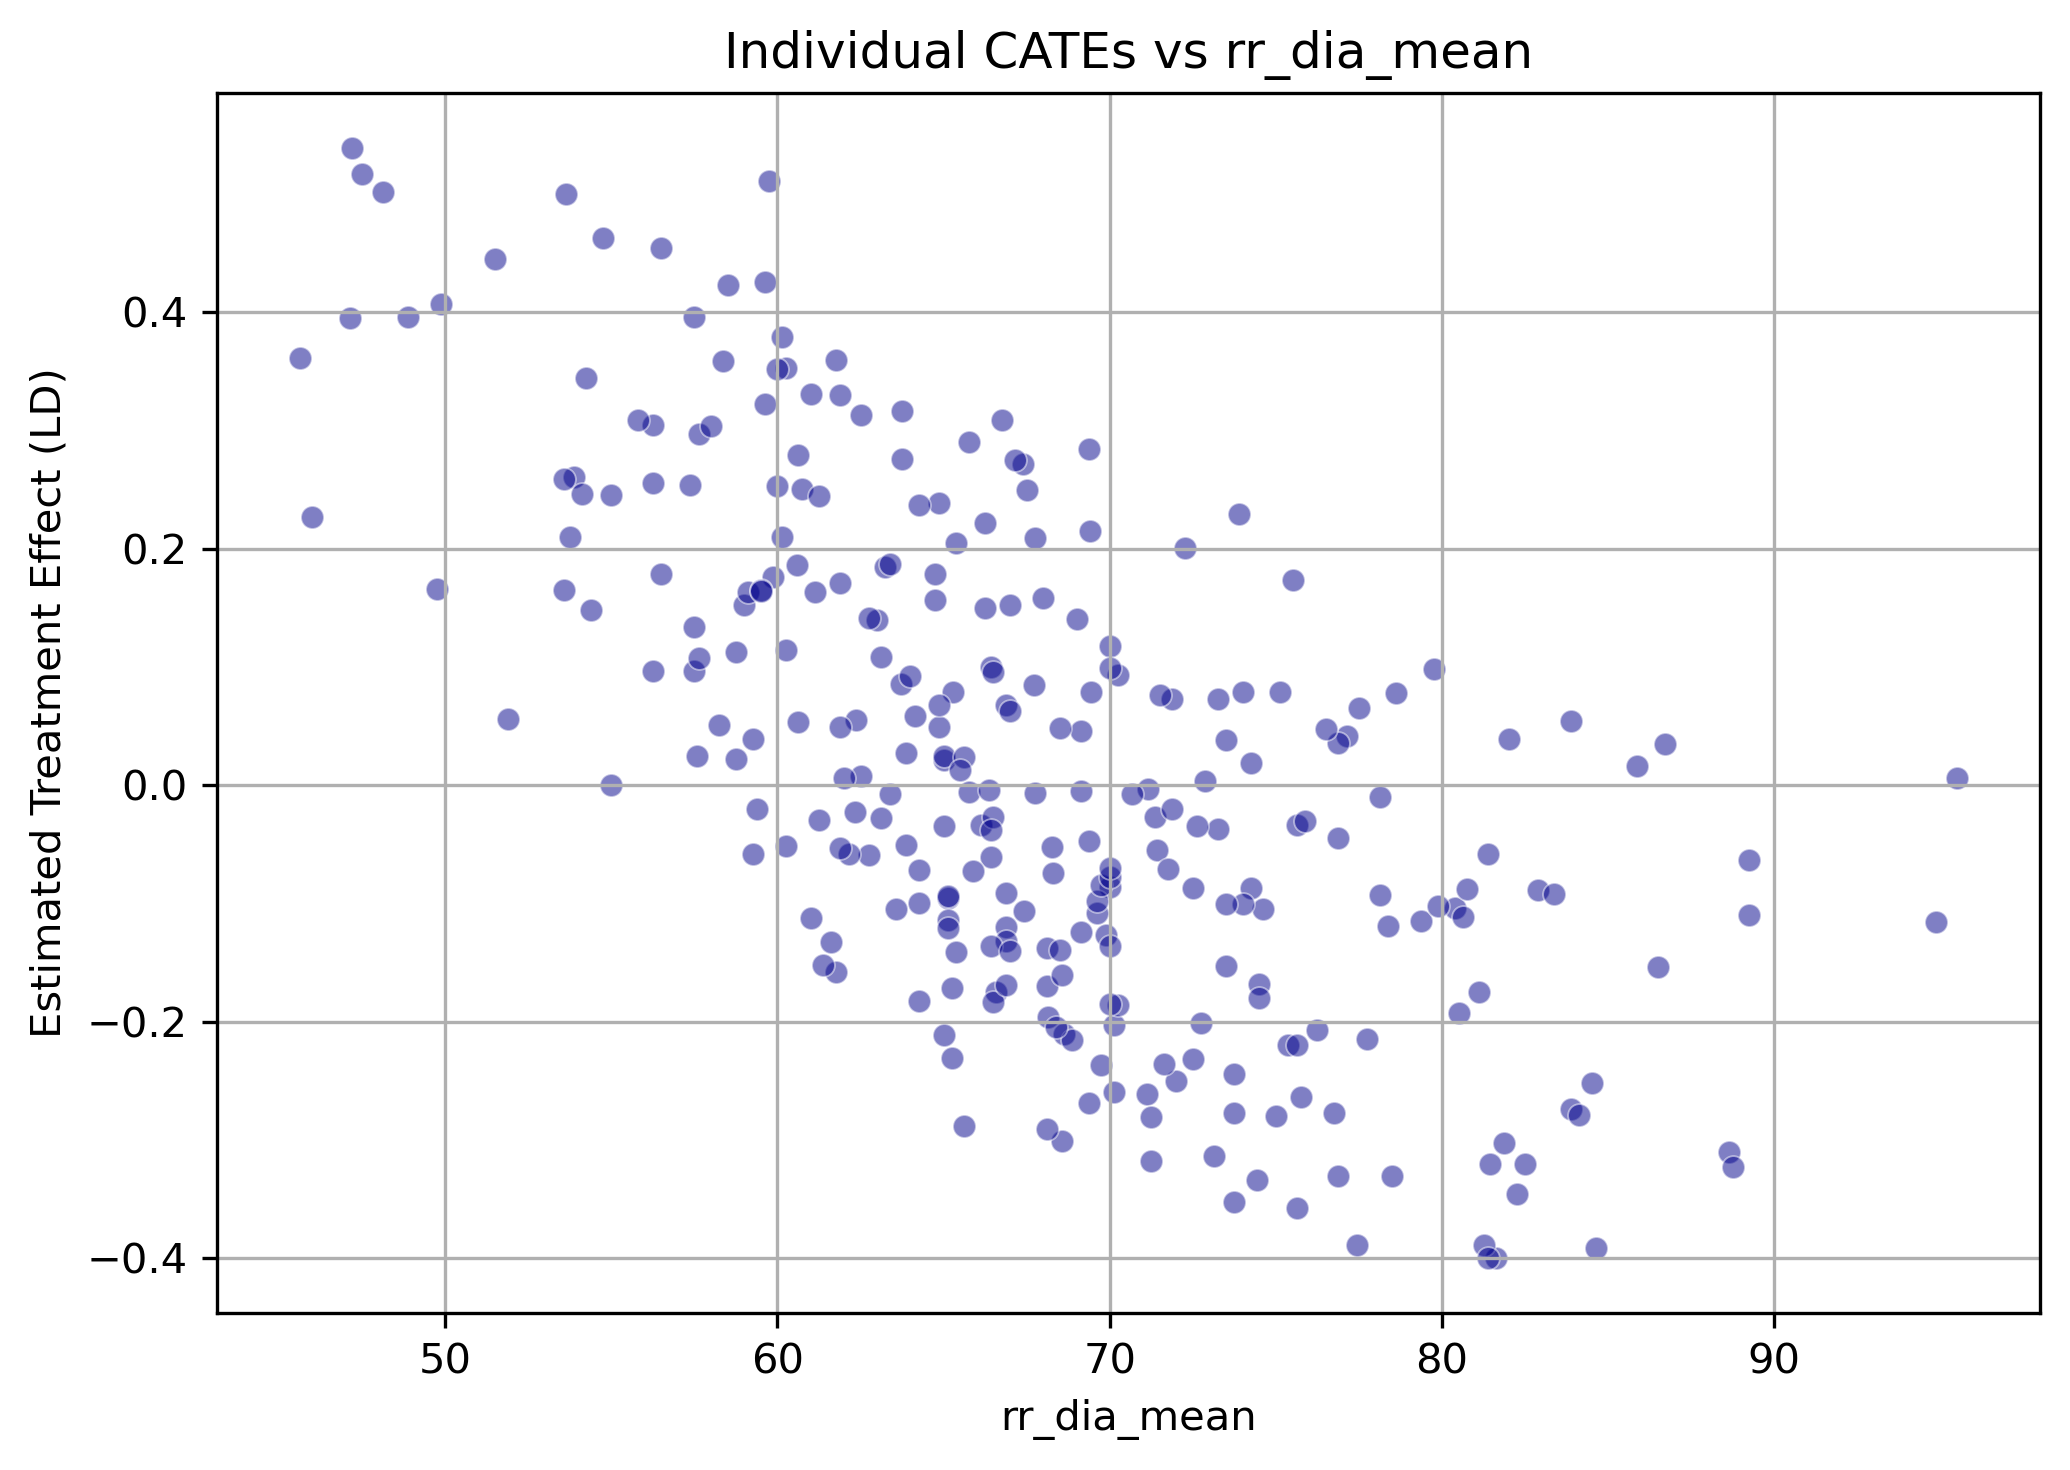

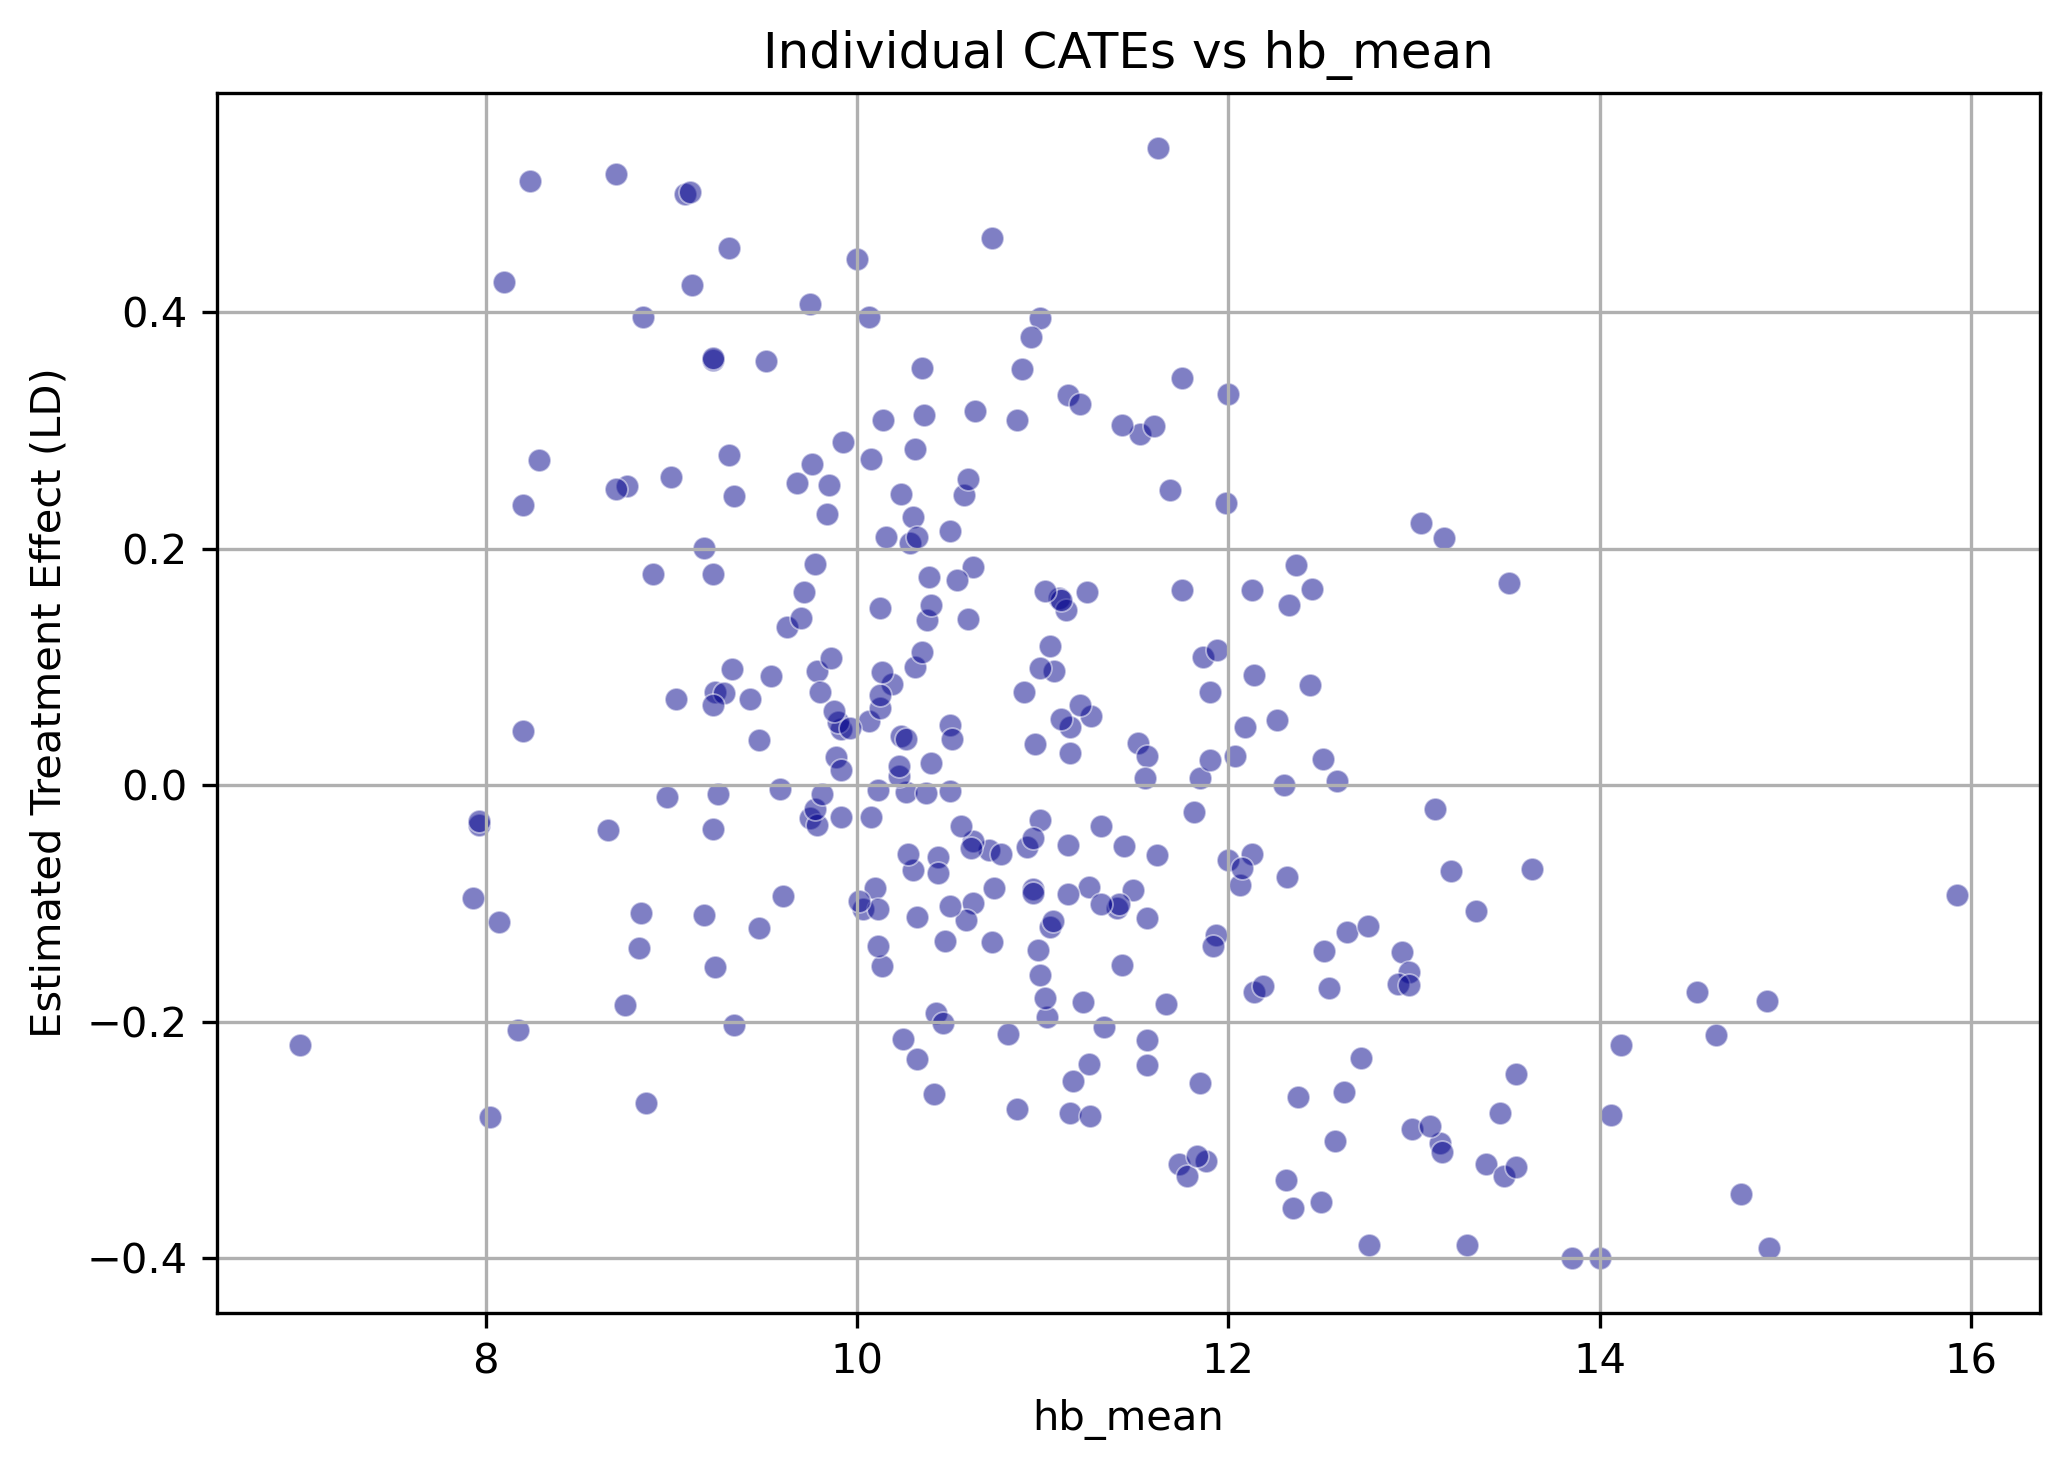

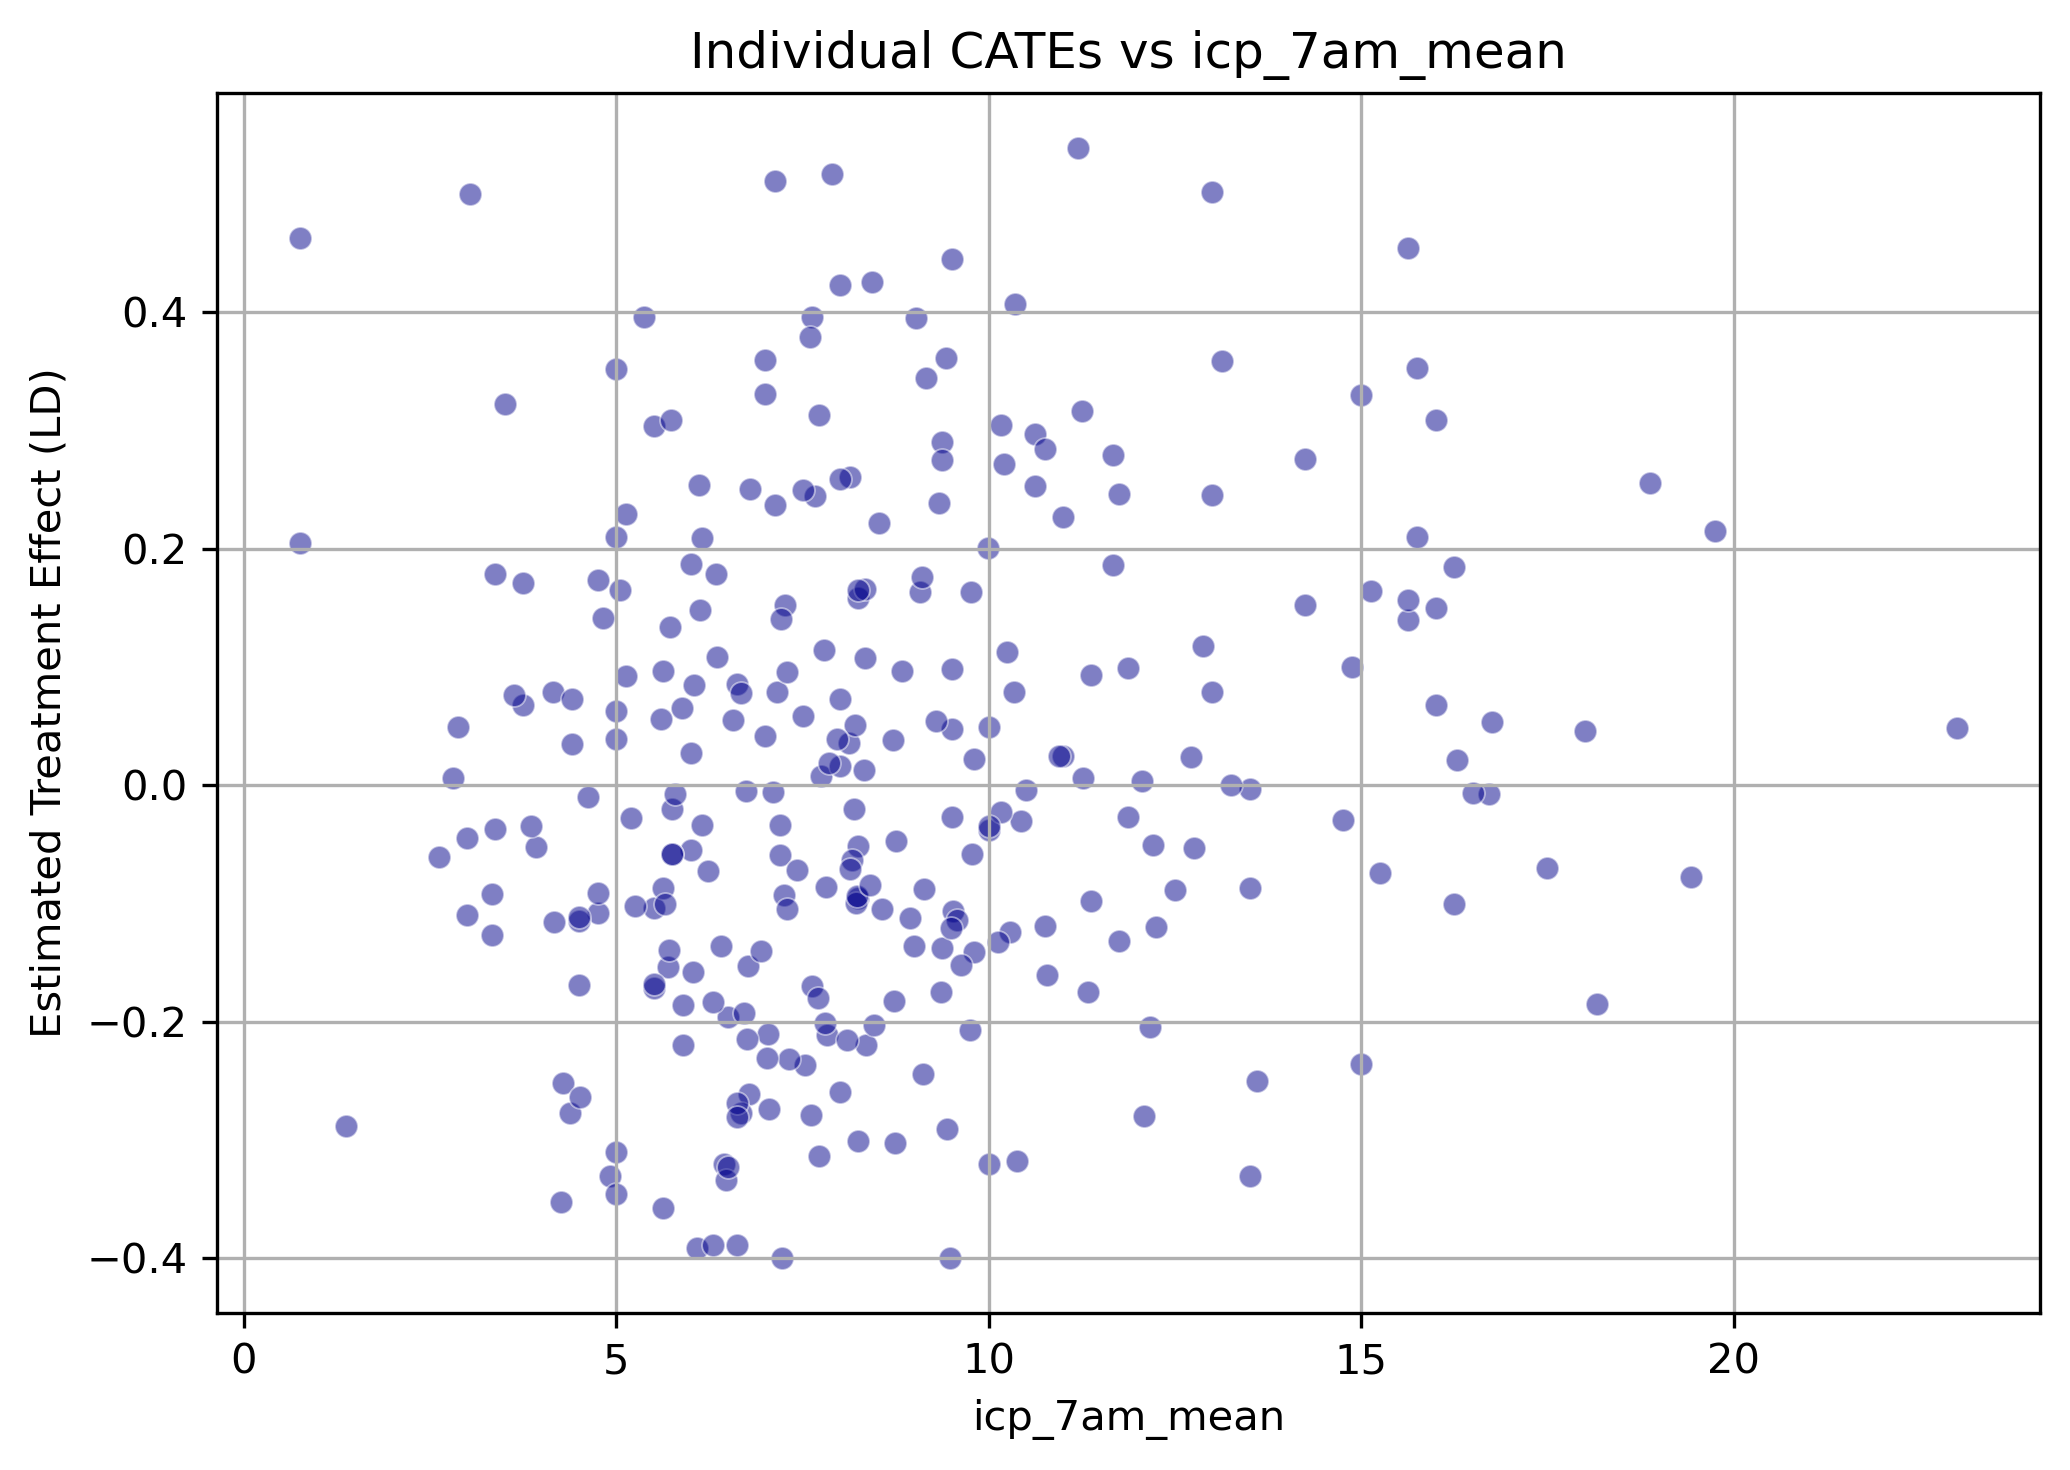

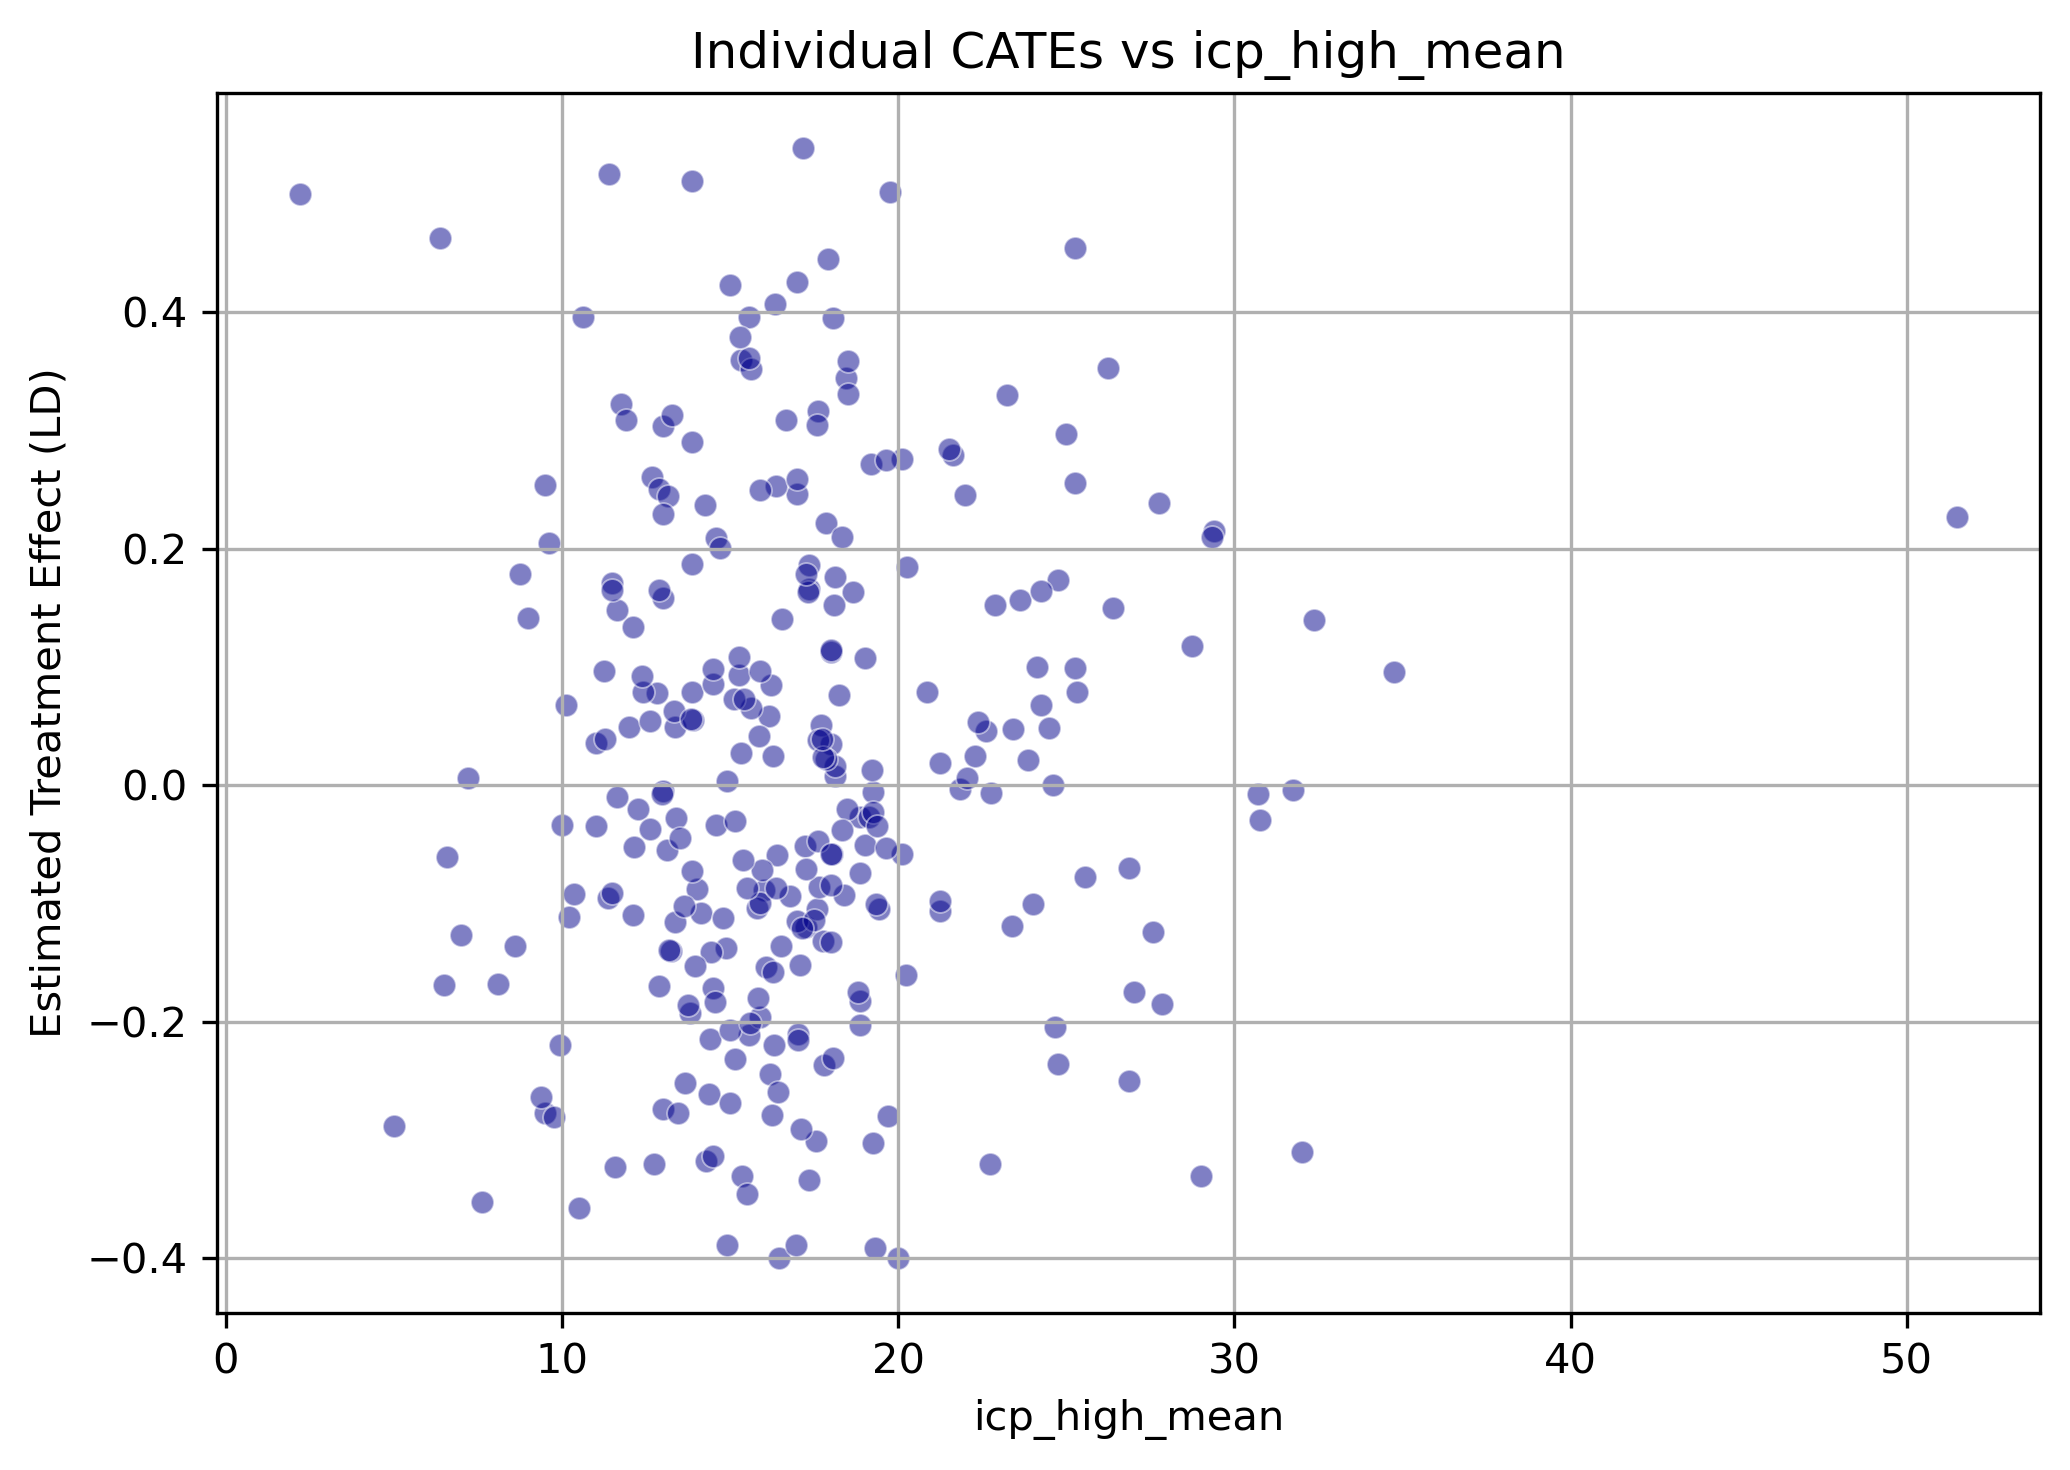

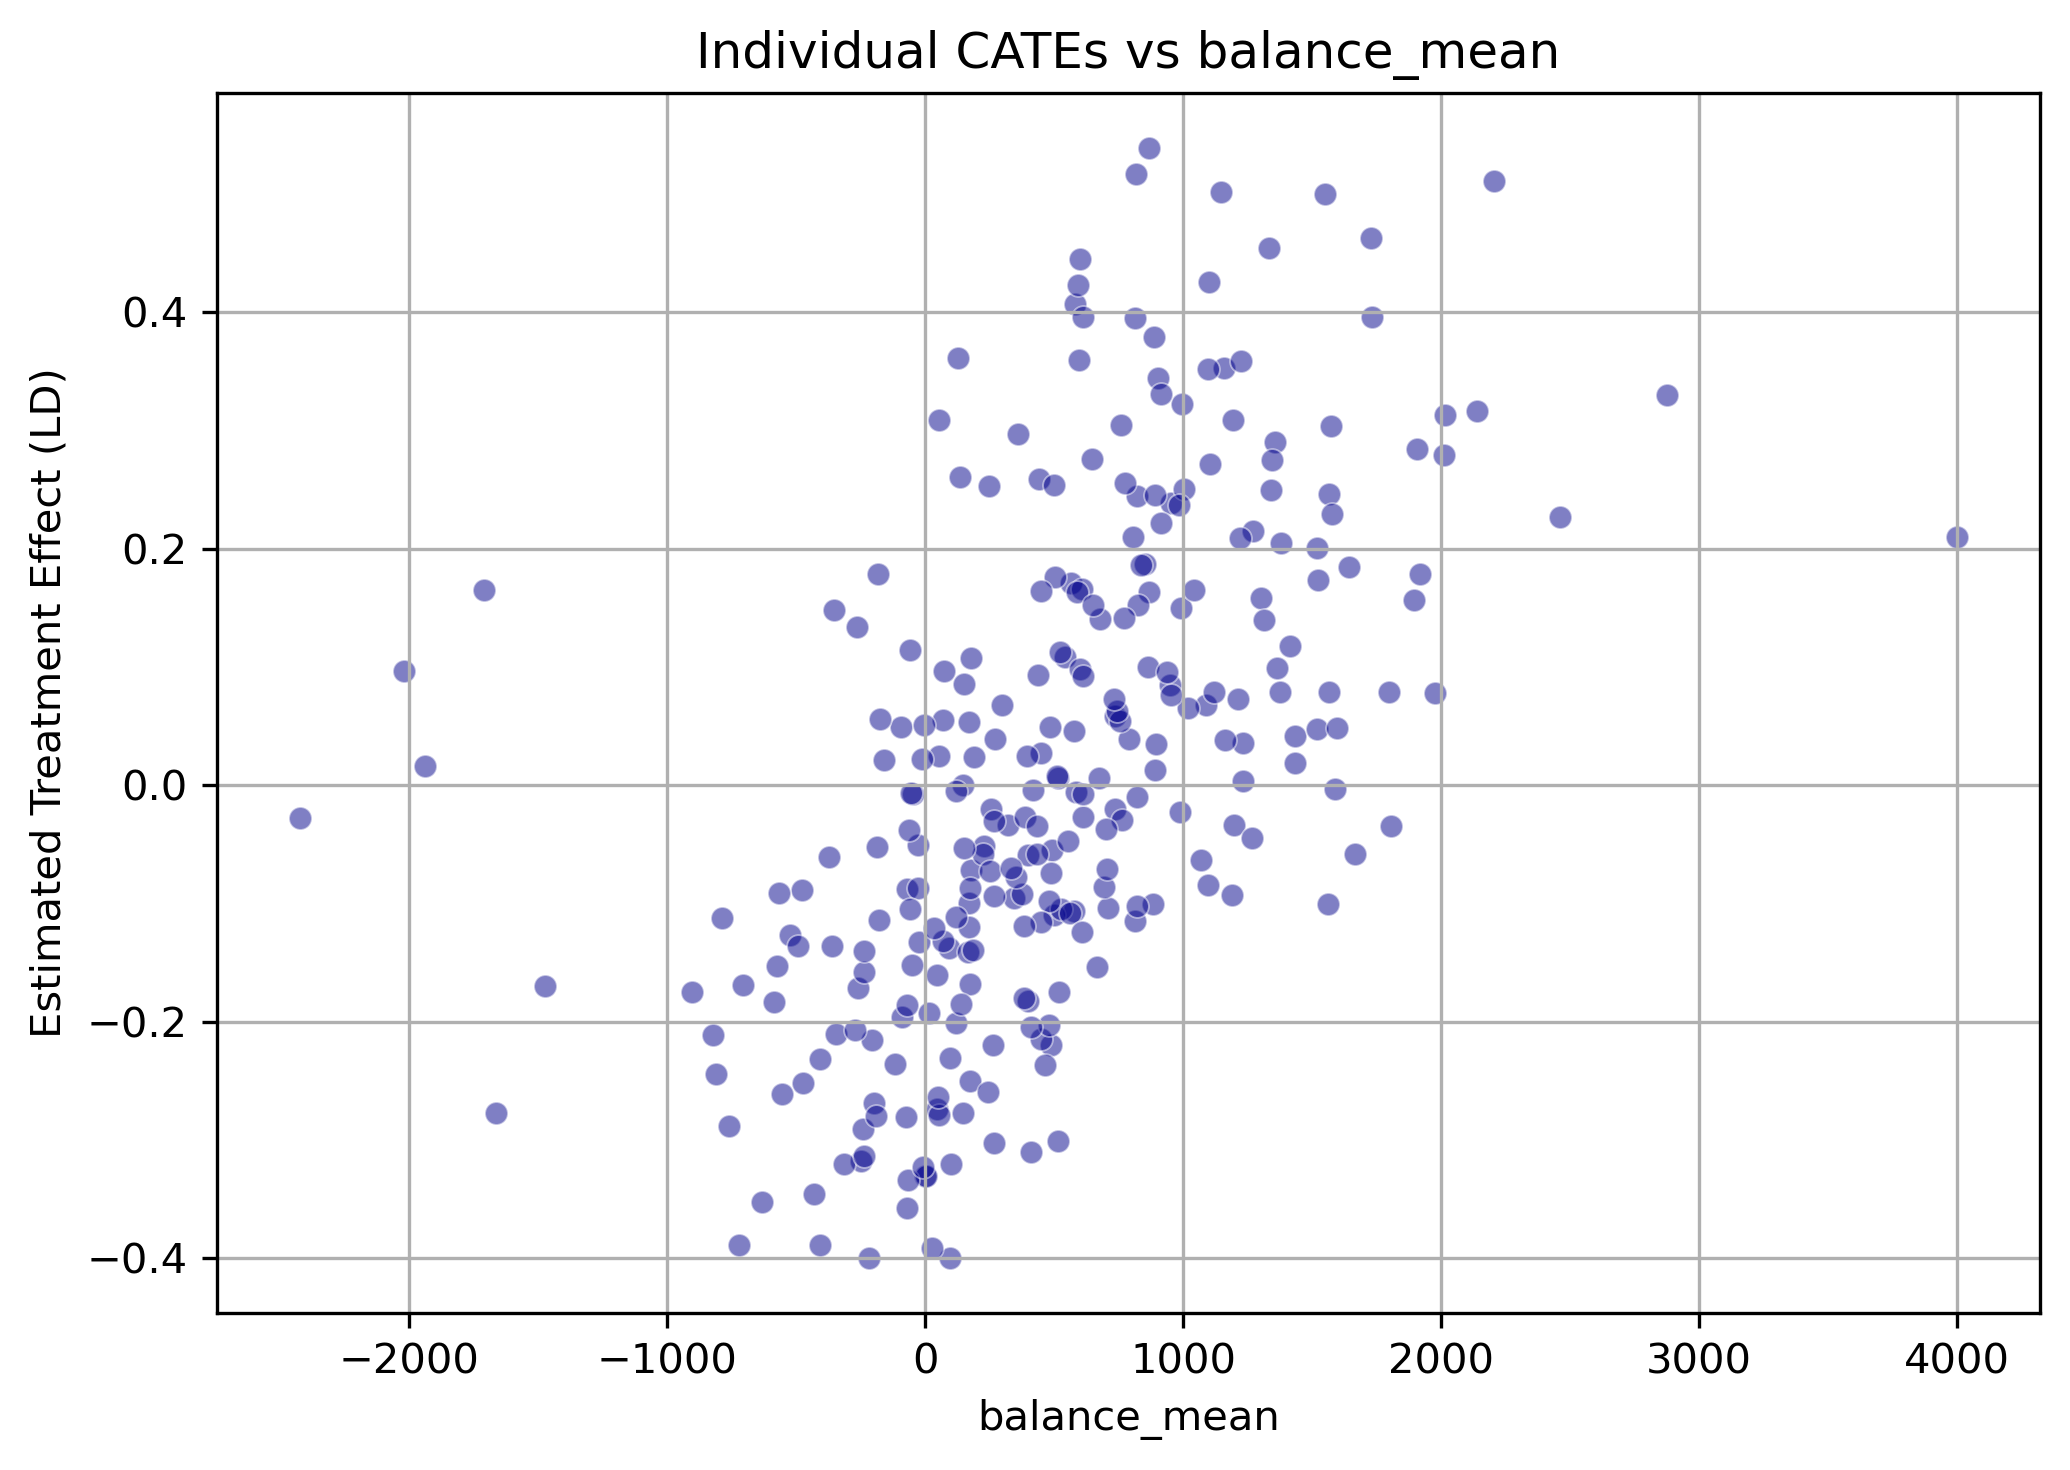

In [6]:
plot_cate_vs_feature(cate_df, 'age')
plot_cate_vs_feature(cate_df, 'aneurysm_size')
plot_cate_vs_feature(cate_df, 'rr_map_mean')
plot_cate_vs_feature(cate_df, 'rr_syst_mean')
plot_cate_vs_feature(cate_df, 'rr_dia_mean')
plot_cate_vs_feature(cate_df, 'hb_mean')
plot_cate_vs_feature(cate_df, 'icp_7am_mean')
plot_cate_vs_feature(cate_df, 'icp_high_mean')
# plot_cate_vs_feature(cate_df, 'csf_mean')
plot_cate_vs_feature(cate_df, 'balance_mean')


In [7]:
dml_model = run_doubleml_analysis(X, Y, T, feature_names)


'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


🎯 Estimated ATE via DoubleML: [-0.06356352]

📏 95% Confidence Interval:
       2.5 %    97.5 %
d -0.509318  0.382191

🧪 Sensitivity Summary:
 ================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
   CI lower  theta lower     theta  theta upper  CI upper
0  -0.55659    -0.181931 -0.063564     0.054804   0.42851

------------------ Robustness Values ------------------
   H_0   RV (%)   RVa (%)
0  0.0  1.62252  0.000473


c:\Users\shrin\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [8]:
import numpy as np
# Estimate CATEs for all
cates_all = cf_model.effect(X)

# Subset to treated patients
treated_mask = T == 1
atte = np.mean(cates_all[treated_mask])

print(f"📊 ATTE (on the treated): {atte:.4f}")


📊 ATTE (on the treated): 0.0040


c:\Users\shrin\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\shrin\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [9]:
atc = np.mean(cates_all[T == 0])
print(f"ATC (on the untreated): {atc:.4f}")


ATC (on the untreated): 0.0181


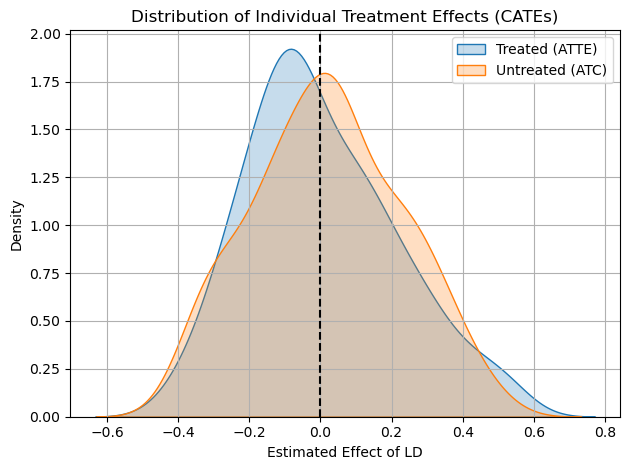

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(cates_all[T == 1], label='Treated (ATTE)', fill=True)
sns.kdeplot(cates_all[T == 0], label='Untreated (ATC)', fill=True)
plt.axvline(0, color='black', linestyle='--')
plt.title("Distribution of Individual Treatment Effects (CATEs)")
plt.xlabel("Estimated Effect of LD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
